# EEG_07f — Preprocessing: Graph & Hypergraph Tensors

Sostituisce EEG_07e. Per ogni trial CSV di Paolo produce:
- `graphs/`             → grafo non-pruned (edge_index + edge_attr)
- `graphs_pruned/`      → grafo con consensus pruning
- `hypergraphs/`        → ipergrafo non-pruned (incidence matrix H)
- `hypergraphs_pruned/` → ipergrafo con consensus pruning

**Sorgente dati**: `data/raw_csv/training_set/PXXX_SYYY/word_img.csv`  
**Shape CSV**: (61 canali × 384 campioni), no header, float32  
**Paradigma**: 1 file .pt per trial — mai file monolitici


In [1]:
import json
import logging
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.signal import hilbert
from tqdm.auto import tqdm


In [2]:
# ============================================================
# CONFIG — modifica qui, poi Kernel → Restart & Run All
# ============================================================

# Solo abs_pcc: è l'unica metrica usata da EEG_13b (hypergraphs_pruned_abs_pcc).
# Metti tutte e 5 ["pcc","abs_pcc","im_pcc","wpli","plv"] solo se serve ablation completa.
METRICS = ["abs_pcc"]

# Metriche usate per il consensus pruning (indipendente da METRICS)
CONSENSUS_METRICS = ["wpli", "plv", "abs_pcc", "im_pcc"]

# Soglia consensus: None = maggioranza (ceil(n/2)); int = fisso
CONSENSUS_K = None

# Top-X% per metric: arco significativo se |valore| >= percentile X
EDGE_THRESHOLD_PCT = 95

# k vicini per iperedge (costruzione matrice di incidenza H)
K_HYPEREDGE = 6

# Salta trial già processati (utile per resume dopo crash)
OVERWRITE = False

# True = rigenera anche i file .pt dei GRAFI (piu lento).
# False = rigenera solo gli IPERGRAFI.
REBUILD_GRAPHS = True

# Filtra soggetti: None = tutti; set(range(74,91)) = solo nuovi soggetti P074-P090.
# I vecchi soggetti (P000-P073) hanno gia gli ipergraf pruned su spinlabs01.
SUBJ_FILTER = set(range(74, 91))

In [3]:
# ============================================================
# SETUP — path, logging, mapping parola → label_idx
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("eeg07f")

# Root di progetto
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve(),
)

CSV_ROOT = project_root / "data" / "raw_csv" / "training_set"
DATA_OUT = project_root / "data"   # graphs_{metric}/ e graphs_pruned_{metric}/ qui sotto

assert CSV_ROOT.exists(), f"CSV_ROOT non trovato: {CSV_ROOT}"
log.info(f"project_root : {project_root}")
log.info(f"CSV_ROOT     : {CSV_ROOT}")

# word → label_idx
_label2idx_path = project_root / "configs" / "label_schemes" / "label2idx.json"
word2label: dict = json.loads(_label2idx_path.read_text())
log.info(f"Vocabolario  : {len(word2label)} parole")

# Verifica metriche configurate
_VALID_METRICS = {"pcc", "abs_pcc", "im_pcc", "wpli", "plv"}
assert all(m in _VALID_METRICS for m in METRICS), f"Metrica non valida in METRICS"
assert all(m in _VALID_METRICS for m in CONSENSUS_METRICS), f"Metrica non valida in CONSENSUS_METRICS"

_eff_k = CONSENSUS_K if CONSENSUS_K is not None else __import__("math").ceil(len(CONSENSUS_METRICS) / 2)
log.info(f"METRICS      : {METRICS}")
log.info(f"Consensus    : {CONSENSUS_METRICS}  k={_eff_k}/{len(CONSENSUS_METRICS)}")
log.info(f"Threshold    : percentile {EDGE_THRESHOLD_PCT} → top {100-EDGE_THRESHOLD_PCT:.0f}%")


20:48:14  INFO      project_root : /home/daniele_u/miralis-hypergraph-imagined-speech
20:48:14  INFO      CSV_ROOT     : /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
20:48:14  INFO      Vocabolario  : 110 parole
20:48:14  INFO      METRICS      : ['abs_pcc']
20:48:14  INFO      Consensus    : ['wpli', 'plv', 'abs_pcc', 'im_pcc']  k=2/4
20:48:14  INFO      Threshold    : percentile 95 → top 5%


In [4]:
# ============================================================
# METRICHE DI CONNETTIVITÀ
# Ogni funzione riceve x: (N_ch, N_samples) float32
# Restituisce matrice (N, N) float32, diagonale = 0
# ============================================================

def _pcc(x: np.ndarray) -> np.ndarray:
    """Pearson Correlation Coefficient."""
    mat = np.corrcoef(x).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def _abs_pcc(x: np.ndarray) -> np.ndarray:
    """Valore assoluto del PCC."""
    return np.abs(_pcc(x))


def _im_pcc(x: np.ndarray) -> np.ndarray:
    """
    Parte immaginaria della coerenza complessa (imaginary coherence).
    Basata sull'analytic signal via Hilbert — insensibile alla conduzione
    di volume (componenti a zero-lag si cancellano).
    Ref: Nolte et al. 2004 (Clin Neurophysiol).
    """
    z = hilbert(x, axis=1)              # segnale analitico (N, T)
    N, T = z.shape
    # Matrice di cross-correlazione normalizzata
    cross = (z @ z.conj().T) / T        # (N, N), unnormalised
    norms = np.sqrt(np.mean(np.abs(z) ** 2, axis=1))   # (N,)
    norm_mat = np.outer(norms, norms) + 1e-12
    coherency = cross / norm_mat        # coerenza complessa (N, N)
    mat = np.imag(coherency).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def _wpli(x: np.ndarray) -> np.ndarray:
    """
    Weighted Phase Lag Index.
    wPLI[i,j] = |E[Im(Sxy)]| / E[|Im(Sxy)|]
    Ref: Vinck et al. 2011 (NeuroImage).
    """
    z = hilbert(x, axis=1)              # (N, T) analytic signal
    N = x.shape[0]
    wpli = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        cross_im = np.imag(z[i] * np.conj(z))  # (N, T)
        num = np.abs(np.mean(cross_im, axis=1))
        den = np.mean(np.abs(cross_im), axis=1) + 1e-10
        wpli[i] = (num / den).astype(np.float32)
    np.fill_diagonal(wpli, 0.0)
    return wpli


def _plv(x: np.ndarray) -> np.ndarray:
    """
    Phase Locking Value.
    PLV[i,j] = |mean_t( exp(i*(phi_i - phi_j)) )|
    Ref: Lachaux et al. 1999 (Human Brain Mapping).
    """
    z = hilbert(x, axis=1)              # (N, T) analytic signal
    phases = z / (np.abs(z) + 1e-10)   # (N, T) unit complex
    N = x.shape[0]
    plv = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        cross = phases[i] * np.conj(phases)     # (N, T)
        plv[i] = np.abs(np.mean(cross, axis=1)).astype(np.float32)
    np.fill_diagonal(plv, 0.0)
    return plv


_METRIC_FNS = {
    "pcc":     _pcc,
    "abs_pcc": _abs_pcc,
    "im_pcc":  _im_pcc,
    "wpli":    _wpli,
    "plv":     _plv,
}


def compute_metric(x: np.ndarray, metric: str) -> np.ndarray:
    """Calcola metrica di connettività per un singolo trial."""
    return _METRIC_FNS[metric](x)


print("Metriche OK:", list(_METRIC_FNS.keys()))


Metriche OK: ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']


In [5]:
# ============================================================
# CONSENSUS PRUNING — majority vote su metriche multiple
# ============================================================

def _significance_mask(mat: np.ndarray, threshold_pct: float) -> np.ndarray:
    """
    Maschera binaria: 1 se |valore| >= percentile threshold_pct dei valori
    off-diagonali. Funziona su metriche sia positive che signed.

    Args:
        mat:           (N, N) matrice di connettività
        threshold_pct: percentile (es. 80 → soglia al p80, top 20% archi)

    Returns: (N, N) bool array, diagonale sempre False
    """
    N = mat.shape[0]
    vals = np.abs(mat)
    np.fill_diagonal(vals, 0.0)
    off_diag = vals[~np.eye(N, dtype=bool)]
    thr = np.percentile(off_diag, threshold_pct)
    mask = (vals >= thr)
    np.fill_diagonal(mask, False)
    return mask


def compute_consensus_mask(
    x: np.ndarray,
    consensus_metrics: list[str],
    threshold_pct: float,
    k: int | None,
) -> np.ndarray:
    """
    Consensus mask: majority vote su più metriche.

    Per ogni metrica in consensus_metrics:
      1. Calcola matrice di connettività
      2. Applica soglia al percentile threshold_pct → maschera binaria

    Somma le maschere → consensus_score[i,j] = n. metriche che concordano.
    Tieni solo gli archi con consensus_score >= k.

    Args:
        x:                 (N, T) trial EEG normalizzato
        consensus_metrics: lista di nomi metrica
        threshold_pct:     soglia per singola metrica (percentile)
        k:                 soglia minima consensus (None = ceil(n/2))

    Returns: (N, N) bool array — True = arco sopravvive al pruning
    """
    n_metrics = len(consensus_metrics)
    eff_k = math.ceil(n_metrics / 2) if k is None else k
    N = x.shape[0]
    vote_sum = np.zeros((N, N), dtype=np.int8)

    for metric in consensus_metrics:
        mat  = compute_metric(x, metric)
        mask = _significance_mask(mat, threshold_pct)
        vote_sum += mask.astype(np.int8)

    consensus = vote_sum >= eff_k
    np.fill_diagonal(consensus, False)
    return consensus


print("Consensus masking OK")


Consensus masking OK


In [6]:
# ============================================================
# COSTRUTTORI GRAFO E IPERGRAFO
# ============================================================

def _adj_to_sparse(adj: np.ndarray):
    """
    Converte matrice di adiacenza (N, N) in edge_index [2, E] + edge_attr [E].
    """
    rows, cols = np.where(adj != 0.0)
    edge_index = torch.tensor(np.stack([rows, cols], axis=0), dtype=torch.long)
    edge_attr  = torch.tensor(adj[rows, cols], dtype=torch.float32)
    return edge_index, edge_attr


def build_graph_dict(
    x_norm: np.ndarray,
    metric: str,
    label: int,
    meta: dict,
    consensus_mask: np.ndarray | None = None,
) -> dict:
    """
    Costruisce dizionario PyG-compatibile per un singolo trial.

    Args:
        x_norm:         (N, T) EEG normalizzato per-canale
        metric:         nome metrica per pesi archi
        label:          class label intero
        meta:           dizionario metadati trial
        consensus_mask: (N, N) bool — se None, nessun pruning

    Returns dict con chiavi: edge_index, edge_attr, x, adj, y, meta
    """
    adj_full = compute_metric(x_norm, metric)           # (N, N) float

    if consensus_mask is not None:
        adj_eff = adj_full * consensus_mask.astype(np.float32)
    else:
        adj_eff = adj_full

    edge_index, edge_attr = _adj_to_sparse(adj_eff)

    return {
        "edge_index": edge_index,                                   # [2, E]
        "edge_attr":  edge_attr,                                    # [E]
        "x":          torch.tensor(x_norm, dtype=torch.float32),   # [N, T]
        "adj":        torch.tensor(adj_eff, dtype=torch.float32),  # [N, N]
        "y":          torch.tensor(label,  dtype=torch.long),
        "meta":       meta,
    }


def _build_incidence_matrix(adj: np.ndarray, k: int) -> np.ndarray:
    """
    Costruisce matrice di incidenza H di shape (N_nodes, N_he_active).

    N_he_active <= N: solo i nodi con almeno 1 connessione generano un HE.
    I nodi isolati (zero connessioni dopo pruning) vengono saltati.

    Questo evita HE triviali (solo self-membership) che non portano
    informazione strutturale all'ipergrafo.

    H[n, e] = 1 se il nodo n appartiene all'iperedge e, altrimenti 0.
    Restituisce shape (N, N_he_active); se tutti isolati -> (N, 0).
    """
    N    = adj.shape[0]
    cols = []   # una colonna per ogni HE attivo

    for i in range(N):
        row    = adj[i].copy()
        row[i] = 0.0                                         # escludi self-loop
        # usa |row| per catturare sia correlazioni positive che negative
        connected = np.where(np.abs(row) > 1e-6)[0]
        if len(connected) == 0:
            continue                                         # nodo isolato -> skip
        # ordina per intensita' decrescente, prendi top-k
        top_k = connected[np.argsort(np.abs(row[connected]))[::-1]][:k]
        members      = np.concatenate([[i], top_k])
        col          = np.zeros(N, dtype=np.float32)
        col[members] = 1.0
        cols.append(col)

    if not cols:
        return np.zeros((N, 0), dtype=np.float32)
    return np.column_stack(cols)   # (N, N_he_active)


def build_hypergraph_dict(
    x_norm: np.ndarray,
    metric: str,
    k_hyperedge: int,
    label: int,
    meta: dict,
    consensus_mask: np.ndarray | None = None,
) -> dict:
    """
    Costruisce dizionario ipergrafo per un singolo trial.
    Usa la matrice di incidenza H invece di edge_index/edge_attr.

    Un iperedge è definito da un nodo centrale + i suoi top-k vicini.
    Se consensus_mask è fornita, solo gli archi che superano il pruning
    contribuiscono alla membership dell'iperedge.
    """
    adj_full = compute_metric(x_norm, metric)

    if consensus_mask is not None:
        adj_eff = adj_full * consensus_mask.astype(np.float32)
    else:
        adj_eff = adj_full

    H = _build_incidence_matrix(adj_eff, k=k_hyperedge)

    return {
        "H":    torch.tensor(H,        dtype=torch.float32),   # [N, N_hyperedges]
        "x":    torch.tensor(x_norm,   dtype=torch.float32),   # [N, T]
        "adj":  torch.tensor(adj_eff,  dtype=torch.float32),   # [N, N]
        "y":    torch.tensor(label,    dtype=torch.long),
        "meta": meta,
    }


print("Graph & hypergraph builders OK")


Graph & hypergraph builders OK


In [7]:
# ============================================================
# I/O — caricamento CSV, normalizzazione, salvataggio .pt
# ============================================================

def load_trial(csv_path: Path) -> np.ndarray:
    """
    Carica un trial CSV di Paolo.
    Shape attesa: (61, 384) — righe=canali, colonne=campioni temporali.
    Nessun header, valori float separati da virgola.
    """
    x = pd.read_csv(csv_path, header=None).values.astype(np.float32)
    if x.ndim != 2:
        raise ValueError(f"Shape inattesa {x.shape} in {csv_path}")
    return x  # (N_ch, N_samples)


def normalize_trial(x: np.ndarray) -> np.ndarray:
    """
    Z-score per-canale: (x - mean) / std su asse temporale.
    Clip std a 1e-6 per evitare divisione per zero.
    """
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1,  keepdims=True).clip(1e-6)
    return (x - mean) / std


def save_pt(data: dict, path: Path) -> None:
    """Salva dizionario come .pt, crea le cartelle necessarie."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(data, path)


print("I/O utilities OK")


I/O utilities OK


In [8]:
# ============================================================
# MAIN LOOP — per sessione → per trial → per metrica
# Consensus mask calcolata UNA VOLTA per trial (non dipende da METRICS)
# ============================================================

def _out_path(base: Path, metric: str, pruned: bool,
              subj_id: int, sess_id: int, trial_idx: int) -> Path:
    """graphs_{metric}/ o graphs_pruned_{metric}/ / P{xxx}_S{yyy}/trial_{zzz}.pt"""
    kind   = "graphs_pruned" if pruned else "graphs"
    folder = f"P{subj_id:03d}_S{sess_id:03d}"
    return DATA_OUT / f"{kind}_{metric}" / folder / f"trial_{trial_idx:03d}.pt"


def _out_path_hg(base: Path, metric: str, pruned: bool,
                 subj_id: int, sess_id: int, trial_idx: int) -> Path:
    kind   = "hypergraphs_pruned" if pruned else "hypergraphs"
    folder = f"P{subj_id:03d}_S{sess_id:03d}"
    return DATA_OUT / f"{kind}_{metric}" / folder / f"trial_{trial_idx:03d}.pt"


def process_session(session_dir: Path, subj_id: int, sess_id: int) -> tuple[int, int]:
    """Processa tutti i trial di una sessione per tutte le METRICS."""
    csv_files = sorted(session_dir.glob("*_img.csv"))
    n_proc = n_skip = 0

    for trial_idx, csv_path in enumerate(
        tqdm(csv_files, desc=f"  P{subj_id:03d}_S{sess_id:03d}", leave=False)
    ):
        word = csv_path.stem.replace("_img", "")
        if word not in word2label:
            n_skip += 1
            continue

        label = word2label[word]

        # Controlla se TUTTI i file di output esistono già
        all_exist = all(
            _out_path(DATA_OUT, m, pruned, subj_id, sess_id, trial_idx).exists() and
            _out_path_hg(DATA_OUT, m, pruned, subj_id, sess_id, trial_idx).exists()
            for m in METRICS for pruned in [False, True]
        )
        if not OVERWRITE and all_exist:
            n_proc += 1
            continue

        # Carica e normalizza (una sola volta per trial)
        x_norm = normalize_trial(load_trial(csv_path))  # (61, 384)

        # Consensus mask — calcolata ONCE per trial, usata da tutte le metriche
        cons_mask = compute_consensus_mask(
            x_norm, CONSENSUS_METRICS, EDGE_THRESHOLD_PCT, CONSENSUS_K
        )

        _meta_base = {
            "subject_id":        subj_id,
            "session_id":        sess_id,
            "trial_idx":         trial_idx,
            "word":              word,
            "consensus_metrics": CONSENSUS_METRICS,
            "consensus_k":       _eff_k,
        }

        # Loop su tutte le metriche richieste
        for metric in METRICS:
            _meta = {**_meta_base, "metric": metric}

            # Grafo non-pruned  (SKIP: set REBUILD_GRAPHS=True per rigenerare)
            if REBUILD_GRAPHS:
                p_g = _out_path(DATA_OUT, metric, False, subj_id, sess_id, trial_idx)
                if OVERWRITE or not p_g.exists():
                    save_pt(build_graph_dict(
                        x_norm, metric, label, {**_meta, "pruned": False}
                    ), p_g)

                # Grafo pruned
                p_gp = _out_path(DATA_OUT, metric, True, subj_id, sess_id, trial_idx)
                if OVERWRITE or not p_gp.exists():
                    save_pt(build_graph_dict(
                        x_norm, metric, label, {**_meta, "pruned": True},
                        consensus_mask=cons_mask,
                    ), p_gp)

            # Ipergrafo non-pruned
            p_h = _out_path_hg(DATA_OUT, metric, False, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_h.exists():
                save_pt(build_hypergraph_dict(
                    x_norm, metric, K_HYPEREDGE, label, {**_meta, "pruned": False}
                ), p_h)

            # Ipergrafo pruned
            p_hp = _out_path_hg(DATA_OUT, metric, True, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_hp.exists():
                save_pt(build_hypergraph_dict(
                    x_norm, metric, K_HYPEREDGE, label, {**_meta, "pruned": True},
                    consensus_mask=cons_mask,
                ), p_hp)

        del x_norm, cons_mask
        n_proc += 1

    return n_proc, n_skip


# ── Avvia ──────────────────────────────────────────────────
_pat = __import__("re").compile(r"^P(\d+)_S(\d+)$")
session_dirs = sorted(
    [d for d in CSV_ROOT.iterdir() if d.is_dir() and _pat.match(d.name)]
)
log.info(f"Directory sessioni: {len(session_dirs)}")
log.info(f"Output per metrica: {[f'graphs_{m}' for m in METRICS]}")

total_proc = total_skip = 0

for session_dir in tqdm(session_dirs, desc="Sessioni"):
    m_tmp = _pat.match(session_dir.name)
    if m_tmp and SUBJ_FILTER is not None and int(m_tmp.group(1)) not in SUBJ_FILTER:
        continue
    m = _pat.match(session_dir.name)
    subj_id, sess_id = int(m.group(1)), int(m.group(2))
    log.info(f"Inizio: {session_dir.name}")
    n_proc, n_skip = process_session(session_dir, subj_id, sess_id)
    total_proc += n_proc
    total_skip += n_skip
    log.info(f"Fine  : {session_dir.name} — {n_proc} proc, {n_skip} skip")

log.info(f"Done. {total_proc} processati, {total_skip} saltati.")


20:48:14  INFO      Directory sessioni: 442
20:48:14  INFO      Output per metrica: ['graphs_abs_pcc']


Sessioni:   0%|          | 0/442 [00:00<?, ?it/s]

20:48:14  INFO      Inizio: P074_S001


  P074_S001:   0%|          | 0/110 [00:00<?, ?it/s]

20:48:14  INFO      Fine  : P074_S001 — 110 proc, 0 skip
20:48:14  INFO      Inizio: P074_S002


...

20:48:20  INFO      Fine  : P090_S003 — 110 proc, 0 skip
20:48:20  INFO      Inizio: P090_S004


  P090_S004:   0%|          | 0/110 [00:00<?, ?it/s]

20:48:22  INFO      Fine  : P090_S004 — 110 proc, 0 skip
20:48:22  INFO      Inizio: P090_S005


  P090_S005:   0%|          | 0/110 [00:00<?, ?it/s]

20:48:24  INFO      Fine  : P090_S005 — 110 proc, 0 skip
20:48:24  INFO      Done. 9324 processati, 0 saltati.


In [9]:
# ============================================================
# VERIFICA — conteggio e struttura per ogni metrica
# ============================================================
import random

for metric in METRICS:
    for kind, keys in [
        (f"graphs_{metric}",          ["edge_index","edge_attr","x","adj","y","meta"]),
        (f"graphs_pruned_{metric}",   ["edge_index","edge_attr","x","adj","y","meta"]),
        (f"hypergraphs_{metric}",      ["H","x","adj","y","meta"]),
        (f"hypergraphs_pruned_{metric}",["H","x","adj","y","meta"]),
    ]:
        base = DATA_OUT / kind
        pts  = list(base.rglob("*.pt")) if base.exists() else []
        if not pts:
            print(f"  [{kind:<35}]  0 file")
            continue
        sample = torch.load(random.choice(pts), weights_only=False)
        missing = [k for k in keys if k not in sample]
        n_e = sample["edge_index"].shape[1] if "edge_index" in sample else "-"
        h_s = tuple(sample["H"].shape) if "H" in sample else "-"
        print(
            f"  [{kind:<35}]  {len(pts):>6} file  "
            f"x={tuple(sample['x'].shape)}  edges={n_e}  H={h_s}  "
            f"{'OK' if not missing else 'MISSING:' + str(missing)}"
        )


  [graphs_abs_pcc                     ]    9324 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_abs_pcc              ]    9324 file  x=(61, 384)  edges=302  H=-  OK
  [hypergraphs_abs_pcc                ]    9324 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_abs_pcc         ]   48207 file  x=(61, 384)  edges=-  H=(61, 48)  OK


## Visualizzazione — Grafi & Ipergrafi per Soggetto/Parola

In [23]:
import json
with open(project_root / "configs" / "label_schemes" / "label2idx.json") as f:
    words = list(json.load(f).keys())
print(f"Ci sono {len(words)} parole. Ecco le prime 10:")
print(words[:10])


Ci sono 110 parole. Ecco le prime 10:
['accendere', 'acqua', 'adesso', 'aiuto', 'amore', 'anche', 'andare', 'anno', 'ansia', 'aprire']


Trial: P000_S001 | acqua | shape=(61, 384)
Consensus mask: 152 archi attivi (threshold p95, majority vote ≥3/4)


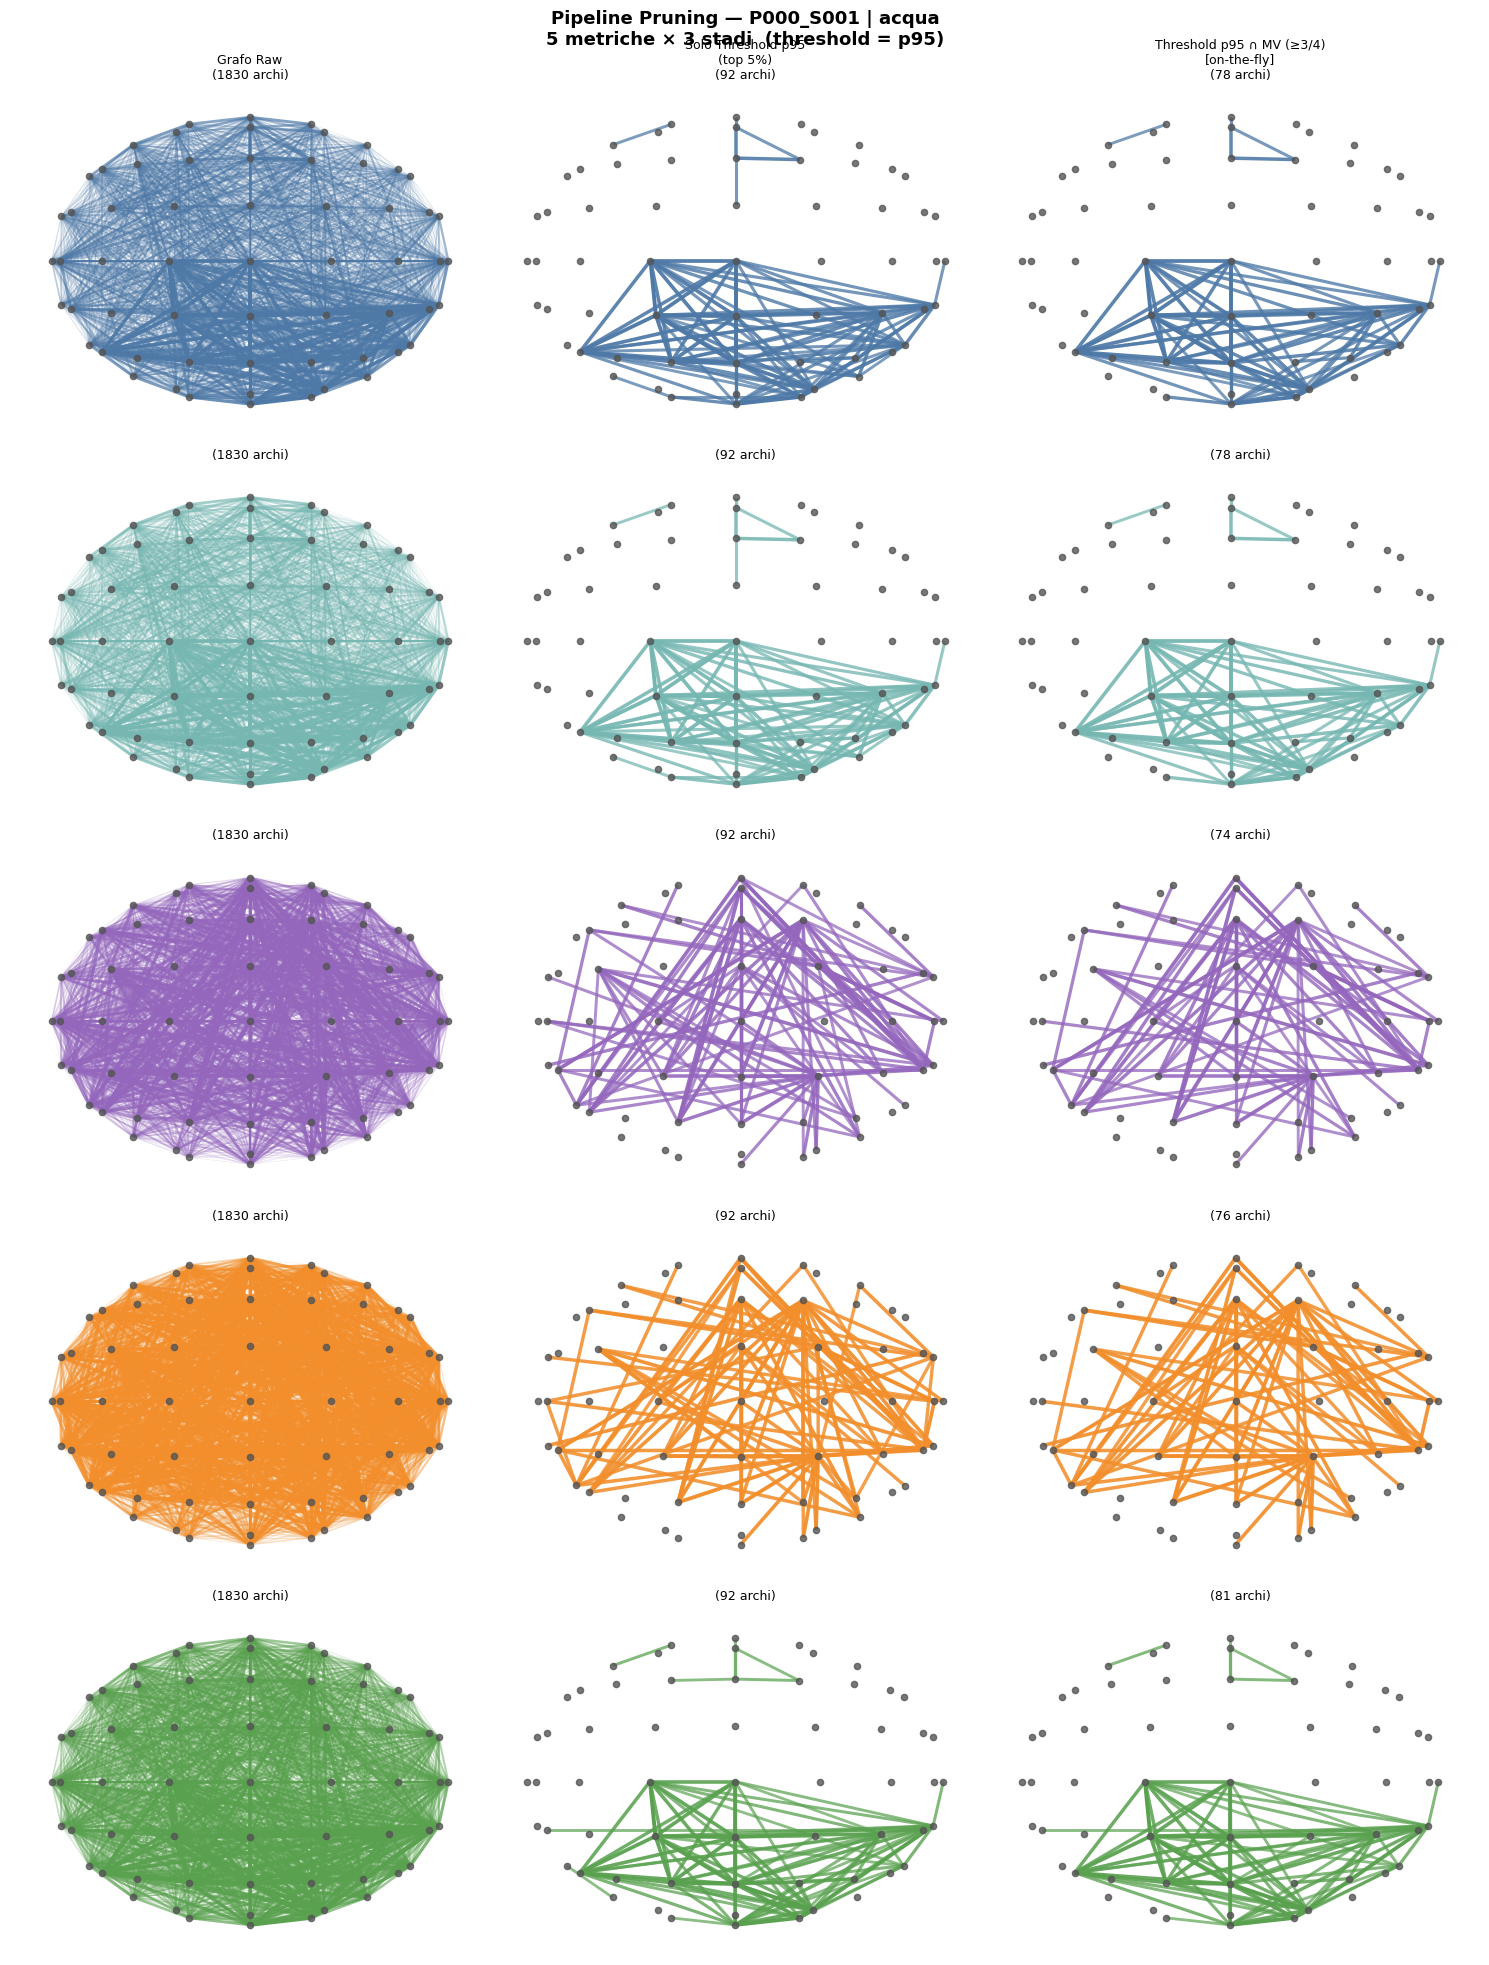


Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/pruning_pipeline_P000_acqua_5metriche.png


In [24]:
# ============================================================
# VISUALIZZAZIONE — Pipeline pruning: 5 metriche × 3 stadi
# Righe: PCC | |PCC| | Im(PCC) | wPLI | PLV
# Colonne: Grafo Raw | Solo Threshold p95 | Majority Vote (on-the-fly)
#
# NOTA: il Majority Vote viene calcolato on-the-fly (non da file .pt)
#       così riflette sempre il threshold corrente, indipendentemente da OVERWRITE.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np

VIZ_SUBJ_ID = 0
VIZ_SESS_ID = 1
VIZ_WORD    = "acqua"

PLOT_METRICS  = ["pcc", "abs_pcc", "im_pcc", "wpli", "plv"]
METRIC_LABELS = {"pcc": "PCC", "abs_pcc": "|PCC|", "im_pcc": "Im(PCC)", "wpli": "wPLI", "plv": "PLV"}
COLORS_ROW    = ["#4e79a7", "#76b7b2", "#9467bd", "#f28e2b", "#59a14f"]

# ── Carica trial ─────────────────────────────────────────────────────────────
_sess_dir = CSV_ROOT / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
x_norm = normalize_trial(load_trial(
    sorted(_sess_dir.glob(f"{VIZ_WORD}_img.csv"))[0]
))
N = x_norm.shape[0]
print(f"Trial: P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d} | {VIZ_WORD} | shape={x_norm.shape}")

# ── Layout nodi 2D (posizioni elettrodi scalpo) ───────────────────────────────
try:
    import mne
    _RENAME   = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
    _BAD      = {"A1", "A2"}
    _mont     = mne.channels.read_custom_montage(
        str(project_root / "src" / "io" / "ebneuro.locs"), coord_frame="head"
    )
    _pos_dict = {_RENAME.get(ch, ch): pos[:2]
                 for ch, pos in _mont.get_positions()["ch_pos"].items()
                 if ch not in _BAD}
    _ch_names = [_RENAME.get(ch, ch) for ch in _mont.ch_names if ch not in _BAD][:N]
    coords    = np.array([_pos_dict.get(ch, [0, 0]) for ch in _ch_names])
    coords   -= coords.min(axis=0)
    coords   /= coords.max(axis=0) + 1e-9
    _pos2d    = {i: coords[i] for i in range(N)}
except Exception:
    _pos2d = nx.circular_layout(nx.path_graph(N))

def _adj_to_G(adj):
    G = nx.Graph()
    G.add_nodes_from(range(adj.shape[0]))
    rows, cols = np.where(np.triu(np.abs(adj) > 1e-6, k=1))
    for r, c in zip(rows, cols):
        G.add_edge(int(r), int(c), weight=float(adj[r, c]))
    return G

# ── Majority vote mask on-the-fly (usa threshold corrente, non file .pt) ──────
cmask = compute_consensus_mask(x_norm, CONSENSUS_METRICS, EDGE_THRESHOLD_PCT, CONSENSUS_K)
print(f"Consensus mask: {int(cmask.sum()//2)} archi attivi (threshold p{EDGE_THRESHOLD_PCT}, "
      f"majority vote ≥{len(CONSENSUS_METRICS)//2+1}/{len(CONSENSUS_METRICS)})")

# ── Figura: 5 righe (metriche) × 3 colonne (stadi) ───────────────────────────
STAGE_TITLES = [
    "Grafo Raw",
    f"Solo Threshold p{EDGE_THRESHOLD_PCT}\n(top {100 - EDGE_THRESHOLD_PCT:.0f}%)",
    f"Threshold p{EDGE_THRESHOLD_PCT} ∩ MV (≥{len(CONSENSUS_METRICS)//2+1}/{len(CONSENSUS_METRICS)})\n[on-the-fly]",
]

fig, axes = plt.subplots(len(PLOT_METRICS), 3, figsize=(15, 4 * len(PLOT_METRICS)))
fig.suptitle(
    f"Pipeline Pruning — P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d} | {VIZ_WORD}\n"
    f"5 metriche × 3 stadi  (threshold = p{EDGE_THRESHOLD_PCT})",
    fontsize=13, fontweight="bold",
)

for row_i, metric in enumerate(PLOT_METRICS):
    color   = COLORS_ROW[row_i]
    adj_raw = compute_metric(x_norm, metric)
    np.fill_diagonal(adj_raw, 0)

    vals    = np.abs(adj_raw.copy())
    thr     = np.percentile(vals[vals > 0], EDGE_THRESHOLD_PCT)
    adj_thr = np.where(vals >= thr, adj_raw, 0.0)
    adj_mv  = adj_thr * cmask.astype(np.float32)   # top-5% metrica corrente ∩ consensus ≥2/4

    Gs = [_adj_to_G(adj_raw), _adj_to_G(adj_thr), _adj_to_G(adj_mv)]

    for col_i, (G, stage_title) in enumerate(zip(Gs, STAGE_TITLES)):
        ax = axes[row_i][col_i]

        # Pesi normalizzati per alpha e larghezza
        weights = [abs(G[u][v]["weight"]) for u, v in G.edges()] or [0]
        w_arr   = np.array(weights)
        if w_arr.max() > 0:
            w_arr = w_arr / w_arr.max()
        edge_w  = [0.3 + 2.5 * w for w in w_arr]
        alpha_e = np.clip(w_arr, 0.15, 1.0)

        nx.draw_networkx_nodes(G, _pos2d, ax=ax, node_size=20,
                               node_color="#555", alpha=0.8)
        if G.number_of_edges() > 0:
            nx.draw_networkx_edges(
                G, _pos2d, ax=ax,
                edge_color=[(*mcolors.to_rgb(color), a) for a in alpha_e],
                width=edge_w,
            )

        # Etichetta riga (sinistra)
        if col_i == 0:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=12,
                          fontweight="bold", rotation=90, labelpad=6)
        # Titolo colonna (solo riga 0) + conteggio archi
        col_hdr = (stage_title + "\n") if row_i == 0 else ""
        ax.set_title(f"{col_hdr}({G.number_of_edges()} archi)", fontsize=9)
        ax.axis("off")

plt.tight_layout()
out_fig = project_root / "figures" / f"pruning_pipeline_P{VIZ_SUBJ_ID:03d}_{VIZ_WORD}_5metriche.png"
plt.savefig(out_fig, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nSalvato: {out_fig}")


In [25]:
def _node_scalar(data_obj) -> np.ndarray:
    if data_obj is None:
        return np.zeros(N_CH)

    d = data_obj if isinstance(data_obj, dict) else data_obj.__dict__

    if "H" in d:
        # ipergrafo: H shape (N, N_he) → quante HE include ogni nodo
        H_np = d["H"].numpy() if isinstance(d["H"], torch.Tensor) else np.array(d["H"])
        v = H_np.sum(axis=1)
    elif "adj" in d:
        # grafo: grado pesato
        adj = d["adj"]
        adj_np = adj.numpy() if isinstance(adj, torch.Tensor) else np.array(adj)
        v = np.abs(adj_np).sum(axis=1)
    elif "edge_index" in d:
        idx = d["edge_index"][0]
        idx_np = idx.cpu().numpy() if isinstance(idx, torch.Tensor) else np.array(idx)
        v = np.bincount(idx_np, minlength=N_CH).astype(float)[:N_CH]
    else:
        return np.zeros(N_CH)

    v = np.asarray(v, dtype=float)
    mx = v.max()
    return v / (mx + 1e-8) if mx > 0 else v


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

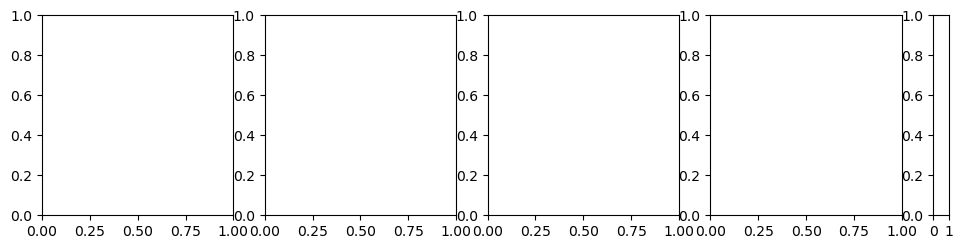

In [26]:
# ============================================================
# NOTA sLORETA / Topomap
# ------------------------------------------------------------
# Nelle celle seguenti, la feature per-canale proiettata è:
#   - Grafo:     grado pesato = sum(|adj|, axis=1)   → quante/quanto forti le connessioni
#   - Ipergrafo: membership    = sum(H, axis=1)       → quanti HE include il canale
#
# Questa è VISUALIZZAZIONE, non entra nel pipeline GNN.
# Per evitare artefatti da volume conduction usare metriche
# VC-immune: wPLI, im_pcc (invece di abs_pcc o pcc grezzo).
# ============================================================

# ============================================================
# TOPOMAP CONNETTIVITÀ SU SCALPO
# ============================================================
import mne, torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path


VIZ_SESS_ID = 5
VIZ_WORD    = "acqua"
N_CH        = 61

# ---- montage ----
_RENAME = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
_BAD    = {"A1", "A2"}
ELOC_FILE = project_root / "src" / "io" / "ebneuro.locs"

_raw_montage = mne.channels.read_custom_montage(str(ELOC_FILE), coord_frame="head")
_ch_pos  = {_RENAME.get(ch, ch): pos
            for ch, pos in _raw_montage.get_positions()["ch_pos"].items()
            if ch not in _BAD}
_montage = mne.channels.make_dig_montage(ch_pos=_ch_pos, coord_frame="head")
ch_names = [_RENAME.get(ch, ch) for ch in _raw_montage.ch_names if ch not in _BAD][:N_CH]

info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
info.set_montage(_montage, on_missing="warn")

# ---- scalare per nodo ----
def _node_scalar(data: dict) -> np.ndarray:
    """
    Grafo     → grado pesato: sum(|adj|, axis=1)
    Ipergrafo → membership:   sum(H,     axis=1)
    """
    if "H" in data:
        v = data["H"].numpy().sum(axis=1)           # (N,)
    elif "adj" in data:
        v = np.abs(data["adj"].numpy()).sum(axis=1)  # (N,)
    else:
        return np.zeros(N_CH)
    mx = v.max()
    return (v / (mx + 1e-8)) if mx > 0 else v

# ---- risolvi trial_idx ----
_sess_dir  = CSV_ROOT / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_trial_idx = next(
    (i for i, p in enumerate(sorted(_sess_dir.glob("*_img.csv")))
     if p.stem == f"{VIZ_WORD}_img"), None
)
if _trial_idx is None:
    raise FileNotFoundError(f"'{VIZ_WORD}' non trovata in {_sess_dir}")

# ---- carica .pt ----
_KINDS = ["graphs", "graphs_pruned", "hypergraphs", "hypergraphs_pruned"]
_loaded = {}
for m in METRICS:
    for k in _KINDS:
        pt = (DATA_OUT / f"{k}_{m}"
              / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
              / f"trial_{_trial_idx:03d}.pt")
        _loaded[(k, m)] = torch.load(pt, weights_only=False) if pt.exists() else None

# ---- figura ----
_COL_TITLES = ["Grafo raw", "Grafo pruned", "HE raw", "HE pruned"]
_CMAP       = "RdYlBu_r"
n_r, n_c    = len(METRICS), len(_KINDS)

fig, axes = plt.subplots(
    n_r, n_c + 1,                          # +1 colonna destra per colorbar
    figsize=(n_c * 2.8 + 0.5, n_r * 2.6),
    gridspec_kw={"width_ratios": [1] * n_c + [0.08]},
)

norm = Normalize(vmin=0, vmax=1)
sm   = ScalarMappable(cmap=_CMAP, norm=norm)
sm.set_array([])

for ri, metric in enumerate(METRICS):
    axes[ri, 0].set_ylabel(
        metric.upper(), fontsize=9, fontweight="bold",
        rotation=0, labelpad=52, va="center",
    )
    for ci, kind in enumerate(_KINDS):
        ax   = axes[ri, ci]
        data = _loaded.get((kind, metric))

        if data is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#aaa")
            ax.axis("off")
            continue

        vals = _node_scalar(data)
        mne.viz.plot_topomap(
            vals, info, axes=ax,
            cmap=_CMAP, vlim=(0, 1),
            contours=5, show=False,
            extrapolate="head",
        )

        # annotazione n. archi / HE attivi
        if "H" in data:
            tag = f"{int((data['H'].sum(axis=0) > 0).sum())} HE"
        else:
            tag = f"{int(data['edge_index'].shape[1] // 2)} archi"
        ax.set_title(tag, fontsize=7, color="#555", pad=2)

    # colorbar per riga (nell'ultima colonna)
    plt.colorbar(sm, cax=axes[ri, -1]).set_ticks([0, 0.5, 1])
    axes[ri, -1].tick_params(labelsize=7)

# intestazioni colonne
for ci, lbl in enumerate(_COL_TITLES):
    axes[0, ci].set_title(lbl, fontsize=9, fontweight="bold", pad=14)

fig.suptitle(
    f"Connettività su scalpo  —  "
    f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  {VIZ_WORD}  |  trial {_trial_idx}",
    fontsize=12, fontweight="bold", y=1.01,
)
fig.tight_layout()

_out = project_root / "figures" / f"topomap_P{VIZ_SUBJ_ID:03d}_{VIZ_WORD}.png"
fig.savefig(_out, dpi=160, bbox_inches="tight")
print(f"Salvato: {_out}")
plt.show()

In [ ]:
# Nota: usa wPLI (immune a volume conduction) invece di abs_pcc.
# abs_pcc ha grado gonfiato da VC sugli elettrodi frontali vicini.

# [ignoring loop detection]
# MEGA-GRID SPAZIALE: Tutte le 5 metriche incluse
# ============================================================

# ---- Parametri di Visualizzazione Aggiornati ----
VIZ_SUBJ_ID = 5
VIZ_SESS_ID = 1
VIZ_WORD    = "acqua"
# Includiamo tutte le metriche presenti nel dataset
METRICS_MAP = ["pcc", "abs_pcc", "im_pcc", "wpli", "plv"] 

def plot_spatial_connectivity(data, info, ax, kind="graph", title=""):
    pos = {i: info['chs'][i]['loc'][:2] for i in range(len(info['chs']))}
    x_coords, y_coords = [p[0] for p in pos.values()], [p[1] for p in pos.values()]
    ax.scatter(x_coords, y_coords, c='black', s=8, zorder=5, alpha=0.4)
    
    if data is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.axis("off"); return

    if "hyper" in kind:
        he_idx = data.get('hyperedge_index', data.get('H'))
        if he_idx is not None:
            if he_idx.shape[0] == N_CH and he_idx.shape[1] != 2:
                ii, jj = torch.where(he_idx > 0); he_idx = torch.stack([ii, jj])
            n_he = int(he_idx[1].max() + 1)
            for e_id in range(0, n_he, 6):
                nodes = he_idx[0][he_idx[1] == e_id].cpu().numpy()
                if len(nodes) >= 3:
                    pts = np.array([pos[n] for n in nodes])
                    try:
                        hull = ConvexHull(pts)
                        ax.add_patch(patches.Polygon(pts[hull.vertices], alpha=0.12, 
                                                     facecolor=plt.cm.tab10(e_id%10), edgecolor='black', lw=0.4))
                    except: pass
            tag = f"{n_he} HE"
    else:
        ei = data.get('edge_index', data.get('adj'))
        if ei is not None:
            if ei.shape[0] == N_CH and ei.shape[1] == N_CH:
                ii, jj = torch.where(ei > 0); ei = torch.stack([ii, jj])
            edge_subset = ei[:, ::5]
            for s, t in edge_subset.t().cpu().numpy():
                if s < len(pos) and t < len(pos):
                    p1, p2 = pos[s], pos[t]
                    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='blue', alpha=0.15, lw=0.5)
            tag = f"{ei.shape[1]//2} archi"

    ax.set_title(f"{title}\n({tag})", fontsize=7, pad=2)
    ax.set_aspect('equal')
    ax.axis('off')

# ---- Generazione Figura ----
n_r, n_c = len(METRICS_MAP), len(_KINDS)
fig, axes = plt.subplots(n_r, n_c, figsize=(n_c * 3.2, n_r * 3.2), squeeze=False)
for ri, m in enumerate(METRICS_MAP):
    # Usiamo annotate invece di ylabel per bypassare ax.axis('off')
    axes[ri, 0].annotate(m.upper(), xy=(-0.4, 0.5), xycoords='axes fraction',
                         fontsize=12, fontweight="bold", ha='center', va='center',
                         rotation=90, color="darkred")
    
    for ci, k in enumerate(_KINDS):
        ax = axes[ri, ci]
        data = _loaded.get((k, m)) 
        plot_spatial_connectivity(data, info, ax, kind=k, title=_COL_TITLES[ci])
# Titoli delle colonne
for ci, lbl in enumerate(_COL_TITLES):
    axes[0, ci].set_title(lbl, fontsize=11, fontweight="bold", pad=20)
fig.suptitle(f"Multi-Metric Spatial Connectivity | P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d} | {VIZ_WORD.upper()} (Trial {_trial_idx})", 
             fontsize=14, fontweight="bold", y=1.03)
# Aumentiamo il margine sinistro per far stare i nomi delle metriche
plt.tight_layout(rect=[0.05, 0, 1, 1]) 
plt.show()


In [ ]:
# ============================================================
# DIPENDENZE ANALISI — installa se assenti
# ============================================================
import subprocess, sys

_PKGS = [
    ("community",       "python-louvain"),
    ("statannotations", "statannotations"),
]
for _imp, _pkg in _PKGS:
    try:
        __import__(_imp)
        print(f"  ✓ {_pkg}")
    except ImportError:
        print(f"  Installing {_pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])
        print(f"  ✓ {_pkg} (installed)")
print("Dependencies OK.")

  ✓ python-louvain
  ✓ statannotations
Dependencies OK.


Topological metrics:   0%|          | 0/110 [00:00<?, ?it/s]

/tmp/ipykernel_1752394/2606631440.py:112: UserWarning: Grafo disconnesso (2 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1752394/2606631440.py:112: UserWarning: Grafo disconnesso (4 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1752394/2606631440.py:112: UserWarning: Grafo disconnesso (3 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():


Trials: 110  |  cluster dist: {0: 18, 1: 27, 2: 21, 3: 44}


/tmp/ipykernel_1752394/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1752394/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1752394/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1752394/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1752394/26066

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07f_topo_metrics_P005_S001.png


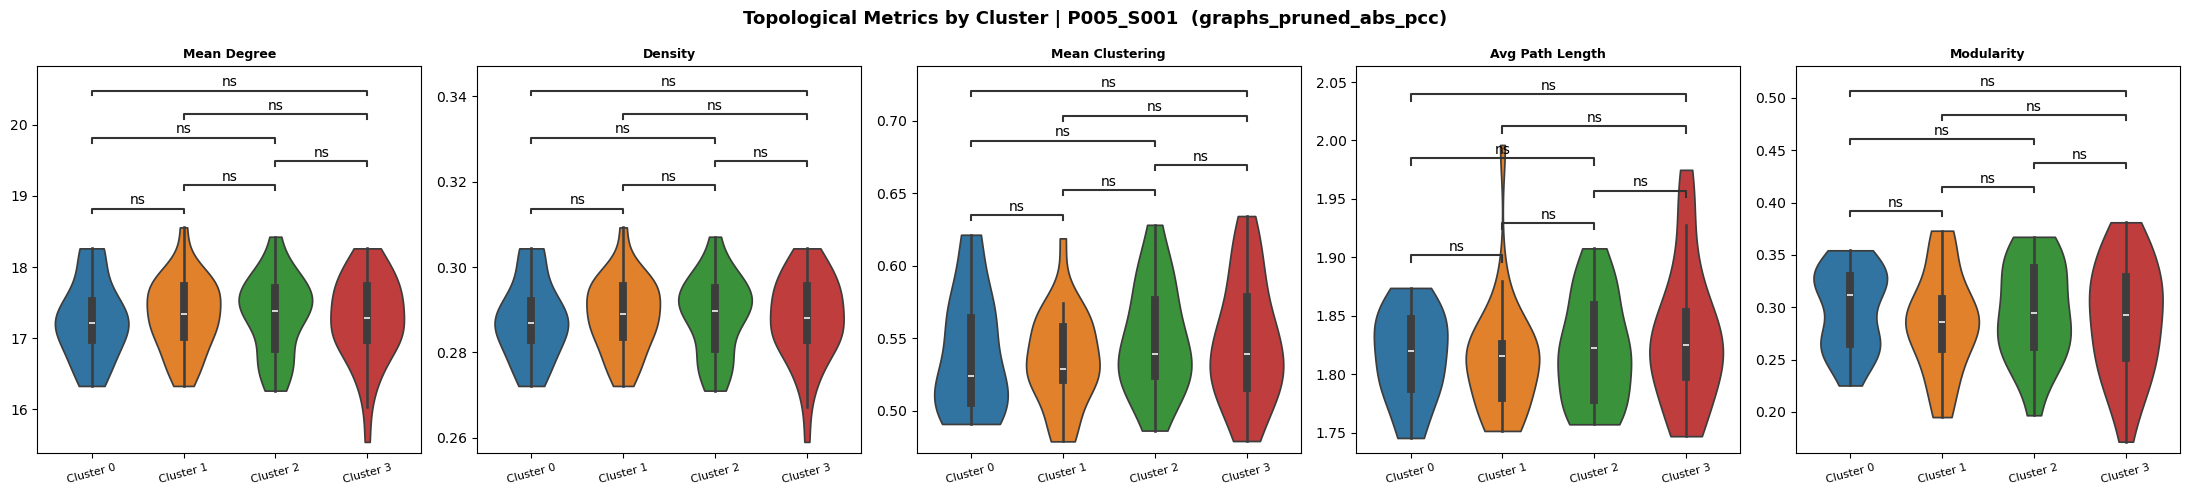

In [ ]:
# ============================================================
# CELL 1 — Metriche topologiche per cluster (violin + Mann-Whitney)
# Dipende da: VIZ_SUBJ_ID, VIZ_SESS_ID, N_CH, DATA_OUT, CSV_ROOT,
#             project_root, word2label (tutti in scope da celle precedenti)
# ============================================================
import json
import warnings
from itertools import combinations

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

try:
    import community as community_louvain
    _HAS_LOUVAIN = True
except ImportError:
    _HAS_LOUVAIN = False
    warnings.warn("python-louvain non installato — colonna 'modularity' sarà NaN")

try:
    from statannotations.Annotator import Annotator as _StatAnnotator
    _HAS_STATANN = True
except ImportError:
    _HAS_STATANN = False

# ── Config ─────────────────────────────────────────────────────────────────────
_TOPO_KIND  = "graphs_pruned_abs_pcc"   # directory .pt da usare

# Nomi cluster (usa CLUSTER_NAMES se definito in scope)
try:
    _CN1 = {i: CLUSTER_NAMES[i] for i in range(4)}
except (NameError, KeyError):
    _CN1 = {i: f"Cluster {i}" for i in range(4)}

# y nel .pt è word_label (0-109) — mappiamo a cluster (0-3)
_lmap1_path = project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json"
if _lmap1_path.exists():
    _lmap1 = {int(k): int(v) for k, v in json.loads(_lmap1_path.read_text()).items()}
    _y1c   = lambda y: _lmap1.get(int(y), int(y)) if int(y) > 3 else int(y)
else:
    _y1c = lambda y: int(y)

(project_root / "figures").mkdir(exist_ok=True)

# ── Calcolo metriche topologiche ───────────────────────────────────────────────
def _topo_metrics(adj_np: np.ndarray) -> dict:
    """
    Riceve matrice adj [N×N] float, restituisce dict metriche scalari.
    avg_path_length: calcolato sulla LCC se il grafo è disconnesso.
    """
    A = (np.abs(adj_np) > 0).astype(float)
    np.fill_diagonal(A, 0.0)
    G = nx.from_numpy_array(A)

    degs        = np.array([d for _, d in G.degree()], dtype=float)
    mean_degree = float(degs.mean())

    N         = A.shape[0]
    n_edges   = int(A.sum()) // 2
    max_edges = N * (N - 1) / 2
    density   = n_edges / max_edges if max_edges > 0 else 0.0

    mean_clust = nx.average_clustering(G)

    if nx.is_connected(G):
        avg_path = nx.average_shortest_path_length(G)
    else:
        _comps = list(nx.connected_components(G))
        if len(_comps) > 1:
            warnings.warn(
                f"Grafo disconnesso ({len(_comps)} comp.) — uso LCC per avg_path",
                stacklevel=2,
            )
        _lcc = G.subgraph(max(_comps, key=len)).copy()
        avg_path = nx.average_shortest_path_length(_lcc) if len(_lcc) > 1 else float("nan")

    if _HAS_LOUVAIN:
        _part = community_louvain.best_partition(G, random_state=42)
        mod   = community_louvain.modularity(_part, G)
    else:
        mod = float("nan")

    return {
        "mean_degree":     mean_degree,
        "density":         density,
        "mean_clustering": mean_clust,
        "avg_path_length": avg_path,
        "modularity":      mod,
    }


# ── Stream trial-by-trial ──────────────────────────────────────────────────────
_sess1     = f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_gdir1     = DATA_OUT / _TOPO_KIND / _sess1
_ptfiles1  = sorted(_gdir1.glob("trial_*.pt"))

if not _ptfiles1:
    raise FileNotFoundError(f"Nessun .pt in {_gdir1}")

_rows1 = []
for _pt in tqdm(_ptfiles1, desc="Topological metrics", leave=True):
    _d = torch.load(_pt, weights_only=False, map_location="cpu")
    _c = _y1c(_d["y"])
    _A = _d["adj"].numpy() if isinstance(_d["adj"], torch.Tensor) else np.asarray(_d["adj"])
    _ti = int(_d["meta"]["trial_idx"])
    try:
        for _mn, _mv in _topo_metrics(_A).items():
            _rows1.append({"trial_idx": _ti, "cluster": _c,
                           "metric": _mn, "value": _mv})
    except Exception as _exc:
        warnings.warn(f"{_pt.name}: {_exc}")

topo_df = pd.DataFrame(_rows1)
print(f"Trials: {topo_df['trial_idx'].nunique()}  |  "
      f"cluster dist: {topo_df.drop_duplicates('trial_idx')['cluster'].value_counts().sort_index().to_dict()}")

# ── Figura: 5 violin ───────────────────────────────────────────────────────────
_MNAMES1 = ["mean_degree", "density", "mean_clustering", "avg_path_length", "modularity"]
fig1, axes1 = plt.subplots(1, 5, figsize=(22, 5))

for ax, mname in zip(axes1, _MNAMES1):
    _sub = topo_df[topo_df["metric"] == mname].dropna(subset=["value"]).copy()
    _sub["cname"] = _sub["cluster"].map(_CN1)

    _present = sorted(_sub["cluster"].unique())
    _order   = [_CN1[c] for c in _present]

    sns.violinplot(
        data=_sub, x="cname", y="value",
        order=_order, palette="tab10",
        inner="box", cut=0, ax=ax,
    )
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(mname.replace("_", " ").title(), fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8, rotation=15)

    # Coppie per annotazione statistica
    _pairs_names = [(_CN1[c1], _CN1[c2])
                    for c1, c2 in combinations(_present, 2)]

    if _HAS_STATANN and _pairs_names:
        try:
            _ann = _StatAnnotator(ax, _pairs_names, data=_sub,
                                  x="cname", y="value", order=_order)
            _ann.configure(test="Mann-Whitney", text_format="star",
                           loc="inside", verbose=False)
            _ann.apply_and_annotate()
        except Exception as _ae:
            warnings.warn(f"statannotations [{mname}]: {_ae}")
    else:
        # Fallback: stelle nel titolo
        _sig = []
        for c1, c2 in combinations(_present, 2):
            g1 = _sub[_sub["cluster"] == c1]["value"].dropna()
            g2 = _sub[_sub["cluster"] == c2]["value"].dropna()
            if len(g1) > 1 and len(g2) > 1:
                _, _p = mannwhitneyu(g1, g2, alternative="two-sided")
                _s = ("***" if _p < 0.001 else "**" if _p < 0.01
                      else "*" if _p < 0.05 else None)
                if _s:
                    _sig.append(f"{_CN1[c1][:4]}v{_CN1[c2][:4]}:{_s}")
        if _sig:
            ax.set_title(
                f"{mname.replace('_',' ').title()}\n{', '.join(_sig)}",
                fontsize=7, fontweight="bold",
            )

fig1.suptitle(
    f"Topological Metrics by Cluster | {_sess1}  ({_TOPO_KIND})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
_fig1_out = project_root / "figures" / f"eeg07f_topo_metrics_{_sess1}.png"
fig1.savefig(_fig1_out, dpi=150, bbox_inches="tight")
print(f"Salvato: {_fig1_out}")
plt.show()

In [ ]:
# ============================================================
# CELL 2b — Mean Adjacency riordinata per Zona Cerebrale
# ------------------------------------------------------------
# Divide i 61 elettrodi in 5 zone anatomiche (10-20 standard).
# Riordina la matrice adj in modo che gli elettrodi della stessa
# zona siano contigui → i blocchi intra-zona vs inter-zona
# diventano visibili.
# ============================================================

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.auto import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
_ADJ_SUBJ_ID = VIZ_SUBJ_ID if "VIZ_SUBJ_ID" in dir() else 0
_ADJ_SESS_ID = VIZ_SESS_ID if "VIZ_SESS_ID" in dir() else 1
_ADJ_METRIC  = "abs_pcc"    # metrica da visualizzare
_ADJ_KIND    = "pruned"     # "pruned" o "raw"
_ADJ_N_WORDS = None         # None = tutti i trial, int = campione casuale

# ── Definizione zone cerebrali (standard 10-20) ───────────────────────────────
BRAIN_ZONES = {
    "Frontale": [
        "Fp1","Fp2","AF3","AF4","AF7","AF8",
        "F1","F2","F3","F4","F5","F6","F7","F8","Fz",
        "FC1","FC2","FC3","FC4","FC5","FC6","FCz",
        "FT7","FT8","FT9","FT10",
    ],
    "Centrale": [
        "C1","C2","C3","C4","C5","C6","Cz",
        "CP1","CP2","CP3","CP4","CP5","CP6","CPz",
    ],
    "Temporale": [
        "T7","T8","TP7","TP8","TP9","TP10",
    ],
    "Parietale": [
        "P1","P2","P3","P4","P5","P6","P7","P8","Pz",
        "PO3","PO4","PO7","PO8","POz",
    ],
    "Occipitale": [
        "O1","O2","Oz","Iz",
    ],
}
ZONE_COLORS = {
    "Frontale":   "#4e79a7",
    "Centrale":   "#f28e2b",
    "Temporale":  "#e15759",
    "Parietale":  "#76b7b2",
    "Occipitale": "#59a14f",
}

# ── Carica nomi canali dal montaggio ─────────────────────────────────────────
import mne
_RENAME  = {"T3":"T7","T4":"T8","T5":"P7","T6":"P8"}
_BAD_CH  = {"A1","A2"}
_mont    = mne.channels.read_custom_montage(
    str(project_root / "src" / "io" / "ebneuro.locs"), coord_frame="head"
)
ch_names_all = [_RENAME.get(ch, ch) for ch in _mont.ch_names if ch not in _BAD_CH]
N_CH_ADJ = min(61, len(ch_names_all))
ch_names_61  = ch_names_all[:N_CH_ADJ]

# ── Calcola ordine riorganizzato per zona ─────────────────────────────────────
ordered_indices = []
zone_boundaries = {}   # zona → (start, end) nel nuovo ordine
for zone, zone_chs in BRAIN_ZONES.items():
    idxs = [i for i, ch in enumerate(ch_names_61) if ch in zone_chs]
    zone_boundaries[zone] = (len(ordered_indices), len(ordered_indices) + len(idxs))
    ordered_indices.extend(idxs)

# Aggiungi eventuali canali non classificati in coda
unclassified = [i for i in range(N_CH_ADJ) if i not in ordered_indices]
if unclassified:
    zone_boundaries["Altro"] = (len(ordered_indices), len(ordered_indices) + len(unclassified))
    ordered_indices.extend(unclassified)
    ZONE_COLORS["Altro"] = "#bab0ac"

print(f"Canali riordinati: {len(ordered_indices)}/{N_CH_ADJ}")
for z, (s, e) in zone_boundaries.items():
    print(f"  {z:12s}: {e-s:2d} canali (pos {s}–{e-1})")

# ── Accumula adj media per cluster ───────────────────────────────────────────
_lmap_path = project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json"
_lmap      = {int(k): int(v) for k,v in json.loads(_lmap_path.read_text()).items()}

kind_str = "graphs_pruned" if _ADJ_KIND == "pruned" else "graphs"
base_dir = DATA_OUT / f"{kind_str}_{_ADJ_METRIC}"
sess_dir = base_dir / f"P{_ADJ_SUBJ_ID:03d}_S{_ADJ_SESS_ID:03d}"

if not sess_dir.exists():
    raise FileNotFoundError(f"Dati non trovati: {sess_dir}\nEsegui prima il main loop.")

pt_files = sorted(sess_dir.glob("*.pt"))
if _ADJ_N_WORDS:
    import random
    pt_files = random.sample(pt_files, min(_ADJ_N_WORDS, len(pt_files)))

cluster_adjs = {c: [] for c in range(4)}
for pt in tqdm(pt_files, desc="Carico .pt"):
    d = torch.load(pt, weights_only=False)
    c = _lmap.get(int(d["y"]), None)
    if c is not None and c < 4:
        cluster_adjs[c].append(np.abs(d["adj"].numpy()[:N_CH_ADJ, :N_CH_ADJ]))

mean_adjs = {}
for c, adjs in cluster_adjs.items():
    if adjs:
        mean_adjs[c] = np.mean(adjs, axis=0)
        print(f"  Cluster {c}: {len(adjs)} trial")

# ── Carica nomi cluster ───────────────────────────────────────────────────────
_cn_path = project_root / "configs" / "label_schemes" / "cluster_names_concr4.json"
try:
    cluster_names_map = json.loads(_cn_path.read_text())
    c_labels = {int(k): v for k,v in cluster_names_map.items()}
except Exception:
    c_labels = {i: f"Cluster {i}" for i in range(4)}

# ── Plot: 2×2 heatmap per cluster + titolo zona ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f"Mean Adjacency ({_ADJ_KIND}) per Cluster — P{_ADJ_SUBJ_ID:03d}_S{_ADJ_SESS_ID:03d} | {_ADJ_METRIC}\n"
    f"Elettrodi riordinati per zona anatomica",
    fontsize=12, fontweight="bold"
)
axes_flat = axes.flatten()

vmax = max(a[ordered_indices][:, ordered_indices].max()
           for a in mean_adjs.values()) if mean_adjs else 1.0

for ci, ax in enumerate(axes_flat):
    if ci not in mean_adjs:
        ax.axis("off"); continue
    adj_r = mean_adjs[ci][np.ix_(ordered_indices, ordered_indices)]

    im = ax.imshow(adj_r, cmap="hot", vmin=0, vmax=vmax, aspect="auto")
    ax.set_title(c_labels.get(ci, f"Cluster {ci}"), fontsize=11)
    ax.set_xlabel("Elettrodo (sorgente)"); ax.set_ylabel("Elettrodo (destinazione)")

    # ── Aggiungi linee di separazione per zona ────────────────────────────────
    current = 0
    for zi, (zone, (s, e)) in enumerate(zone_boundaries.items()):
        n = e - s
        if n == 0: continue
        color = ZONE_COLORS.get(zone, "#888")
        # Linee verticali e orizzontali di separazione
        if current > 0:
            ax.axhline(current - 0.5, color="white", linewidth=1.2, alpha=0.8)
            ax.axvline(current - 0.5, color="white", linewidth=1.2, alpha=0.8)
        # Label zona sull'asse X (in basso, ruotata)
        ax.text(current + n/2, adj_r.shape[0] + 1.5, zone[:3],
                ha="center", va="top", fontsize=7, color=color, fontweight="bold")
        current += n

    # ── Tick labels ogni 10 canali ────────────────────────────────────────────
    tick_pos = list(range(0, len(ordered_indices), 10))
    tick_lab = [ch_names_61[ordered_indices[p]] for p in tick_pos]
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lab, rotation=45, fontsize=7)
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lab, fontsize=7)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="|adj|")

# Legenda zone
patches = [mpatches.Patch(color=c, label=z) for z,c in ZONE_COLORS.items()]
fig.legend(handles=patches, loc="lower center", ncol=len(ZONE_COLORS),
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
out_adj = project_root / "figures" / f"mean_adj_by_zone_P{_ADJ_SUBJ_ID:03d}_{_ADJ_KIND}_{_ADJ_METRIC}.png"
plt.savefig(out_adj, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_adj}")


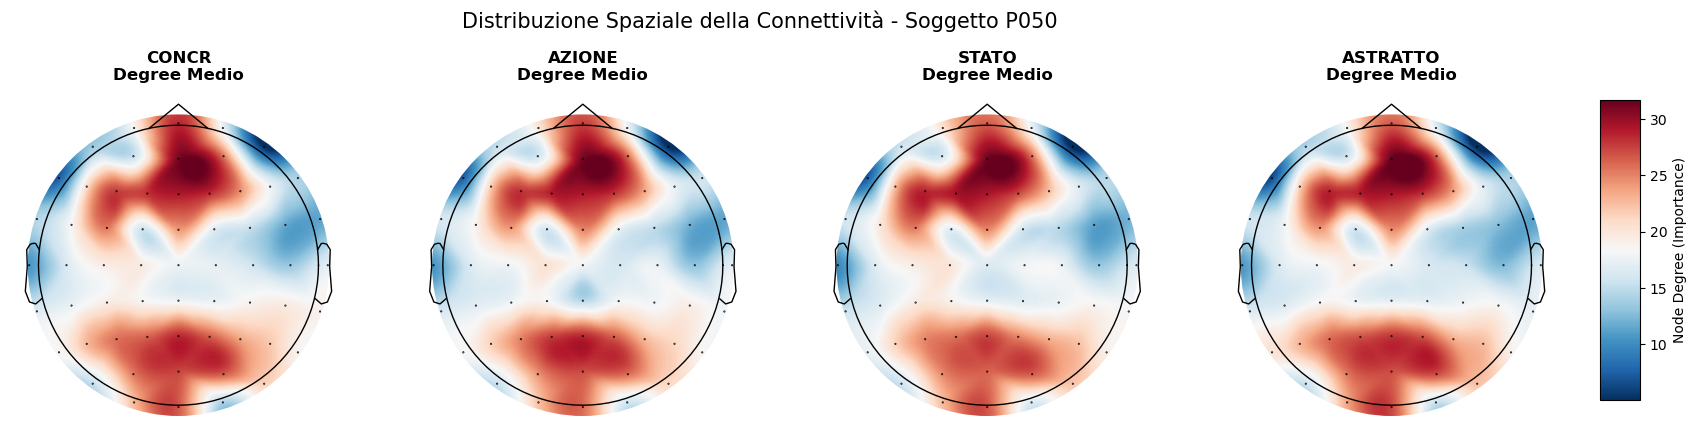

In [ ]:
import torch
import numpy as np
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import json

# --- CONFIGURAZIONE ---
subject_id = "P050"
metric = "wpli"  # VC-immune: preferire wPLI o im_pcc su abs_pcc
base_path = project_root / "data" / f"graphs_pruned_{metric}"

ELOC_FILE = project_root / "src" / "io" / "ebneuro.locs"

_raw_montage = mne.channels.read_custom_montage(str(ELOC_FILE), coord_frame="head")
_ch_pos  = {_RENAME.get(ch, ch): pos
            for ch, pos in _raw_montage.get_positions()["ch_pos"].items()
            if ch not in _BAD}
_montage = mne.channels.make_dig_montage(ch_pos=_ch_pos, coord_frame="head")
ch_names = [_RENAME.get(ch, ch) for ch in _raw_montage.ch_names if ch not in _BAD][:N_CH]

info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
info.set_montage(_montage, on_missing="warn")

# 1. Caricamento Mapping
with open(project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json", "r") as f:
    word2cluster = json.load(f)
with open(project_root / "configs" / "label_schemes" / "cluster_names_concr4.json", "r") as f:
    cluster_names = json.load(f)

# 3. Raccolta Degree per Classe
cluster_degrees = {int(k): [] for k in cluster_names.keys()}
pt_files = list(base_path.glob(f"{subject_id}_S*/*.pt"))

for f in pt_files:
    d = torch.load(f, weights_only=False)
    c_idx = int(word2cluster[str(int(d['y']))])
    # Calcoliamo il degree di ogni nodo (somma delle connessioni incidenti)
    adj = d['adj'].numpy() > 0
    degree = np.sum(adj, axis=1)
    cluster_degrees[c_idx].append(degree)

# 4. Plot delle Topomaps
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Cerchiamo il valore massimo per avere la stessa scala di colori (vmax)
all_means = [np.mean(cluster_degrees[c], axis=0) for c in cluster_degrees if cluster_degrees[c]]
global_vmax = np.max(all_means) if all_means else 1
global_vmin = np.min(all_means) if all_means else 0

for i, c_idx in enumerate(sorted(cluster_degrees.keys())):
    if not cluster_degrees[c_idx]: continue
    
    mean_degree = np.mean(cluster_degrees[c_idx], axis=0)
    
    im, _ = mne.viz.plot_topomap(mean_degree, info, axes=axes[i], show=False, 
                                 cmap='RdBu_r', contours=0, sensors=True,
                                 vlim=(global_vmin, global_vmax))
    
    axes[i].set_title(f"{cluster_names[str(c_idx)]}\nDegree Medio", fontweight='bold')

# Aggiungiamo una colorbar comune
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
clb = fig.colorbar(im, cax=cbar_ax)
clb.set_label('Node Degree (Importance)')

plt.suptitle(f"Distribuzione Spaziale della Connettività - Soggetto {subject_id}", fontsize=15)
plt.show()


In [ ]:
# ============================================================
# CELL 3 — sLORETA Brain Source Imaging (Visualizzazione)
# ------------------------------------------------------------
# Cosa viene proiettato:
#   Feature per-canale = grado pesato dalla matrice adj (abs_pcc pruned)
#     => degree[ch] = sum(adj[ch, :] > 0, axis=0)  (grado binario)
#
# Pipeline:
#   1. Carica .pt da graphs_pruned_{metric}
#   2. Calcola degree per cluster semantico (media su tutti i trial)
#   3. Costruisce MNE EvokedArray (1 canale = 1 elettrodo, 1 timestep)
#   4. Forward solution: fsaverage (BEM), EEG-only
#   5. Inverse: sLORETA (MNE minimum_norm.apply_inverse, method="sLORETA")
#   6. Proietta in spazio cortex e visualizza via Plotly
#
# NOTA: Questo è puramente descrittivo — non entra nel training GNN.
# ============================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import numpy as np
import torch
import mne
import json
import os.path as op
from mne.datasets import fetch_fsaverage
from pathlib import Path

# 1. SETUP AMBIENTE E MAPPING
fs_dir = fetch_fsaverage(verbose=False)
subjects_dir = op.dirname(fs_dir)
src_fs = op.join(fs_dir, 'bem', 'fsaverage-ico-5-src.fif')
bem_fs = op.join(fs_dir, 'bem', 'fsaverage-5120-5120-5120-bem-sol.fif')

# Caricamento Mapping Cluster
_map_path = project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json"
_name_path = project_root / "configs" / "label_schemes" / "cluster_names_concr4.json"

with open(_map_path, "r") as f:
    LID2C = json.load(f)
with open(_name_path, "r") as f:
    C_NAMES = json.load(f)

# Forza visualizzazione VS Code
pio.renderers.default = "notebook_connected"

def plot_cluster_averages_3d_plotly(subject_id, metric="abs_pcc"):
    # 1. Caricamento dati
    cluster_data_acc = {c: [] for c in range(4)}
    subj_files = list((project_root / "data" / f"graphs_pruned_{metric}").glob(f"{subject_id}_S*/*.pt"))
    
    if not subj_files:
        print(f"Nessun dato trovato per {subject_id}")
        return

    for f in subj_files:
        d = torch.load(f, weights_only=False)
        # Usiamo LID2C caricato sopra
        c_id = int(LID2C.get(str(int(d['y'])), d['y']))
        degree = np.sum(d['adj'].numpy() > 0, axis=1)
        if c_id < 4:
            cluster_data_acc[c_id].append(degree)

    # 2. Setup Forward/Inverse
    fwd = mne.make_forward_solution(info, trans='fsaverage', src=src_fs, bem=bem_fs, eeg=True, verbose=False)
    inv = mne.minimum_norm.make_inverse_operator(info, fwd, mne.make_ad_hoc_cov(info), verbose=False)

    cluster_stcs = {}
    global_max = 0
    coords = None

    # 3. Source Estimation
    for c_id, dl in cluster_data_acc.items():
        if not dl: continue
        mean_degree = np.mean(dl, axis=0)
        evoked = mne.EvokedArray(mean_degree[:, np.newaxis], info)
        evoked.set_eeg_reference(projection=True).apply_proj()
        
        stc = mne.minimum_norm.apply_inverse(evoked, inv, lambda2=1./9., method="sLORETA", verbose=False)
        vals = stc.data.mean(axis=1)
        cluster_stcs[c_id] = vals
        global_max = max(global_max, vals.max())
        
        if coords is None:
            s = inv["src"]
            coords = np.vstack([s[0]["rr"][s[0]["vertno"]], s[1]["rr"][s[1]["vertno"]]])

    # 4. Plotly 2x2
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "scene"}]*2, [{"type": "scene"}]*2],
        subplot_titles=[C_NAMES.get(str(c), f"Cluster {c}") for c in range(4)],
        horizontal_spacing=0.03, vertical_spacing=0.05
    )

    for i, c_id in enumerate(sorted(cluster_stcs.keys())):
        r, c = (i // 2) + 1, (i % 2) + 1
        scene_name = f"scene{i+1}" if i > 0 else "scene"
        vals = cluster_stcs[c_id]

        fig.add_trace(
            go.Scatter3d(
                x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
                mode='markers',
                marker=dict(
                    size=3, color=vals, colorscale='Viridis',
                    cmin=0, cmax=global_max, opacity=0.85,
                    showscale=(i == 1)
                )
            ),
            row=r, col=c
        )

        fig.layout[scene_name].update(
            xaxis_visible=False, yaxis_visible=False, zaxis_visible=False,
            bgcolor="black",
            camera=dict(eye=dict(x=0, y=0, z=2.5)) # Vista dall'alto di default
        )
        fig.layout.annotations[i].update(text=f"<b>{C_NAMES.get(str(c_id), c_id)}</b>")

    fig.update_layout(
        title=f"Cluster Brain Signatures - {subject_id}",
        width=1000, height=900,
        paper_bgcolor="black", font=dict(color="white"),
        margin=dict(l=5, r=5, t=80, b=5),
        uirevision="constant"
    )

    fig.show()

# ESECUZIONE
plot_cluster_averages_3d_plotly("P050")


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


/tmp/ipykernel_1752394/1188192056.py:49: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inv = mne.minimum_norm.make_inverse_operator(info, fwd, mne.make_ad_hoc_cov(info), verbose=False)
/tmp/ipykernel_1752394/1188192056.py:49: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inv = mne.minimum_norm.make_inverse_operator(info, fwd, mne.make_ad_hoc_cov(info), verbose=False)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


## Esportazione Plot per Tutti i Soggetti

Three plot types saved to `data/processed/graph_comparison/PXXX/`:
- **adj_matrices_PXXX.png** -- 5 metriche x 3 stadi di adiacenza (heatmap)
- **graph_viz_PXXX.png** -- 5 metriche x 3 stadi (visualizzazione grafo su scalpo)
- **comparison_PXXX_graphs_pruned_{metric}.png** -- mean adj x cluster + diff pairwise

In [ ]:
# ============================================================
# SETUP -- graph_comparison export
# ============================================================
import json as _json_gc, re as _re_gc
import networkx as nx
import matplotlib.colors as mcolors
from itertools import combinations
from matplotlib.colors import TwoSlopeNorm
try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    def _tqdm(x, **kw): return x

GC_OUT = project_root / 'data' / 'processed' / 'graph_comparison'
GC_OUT.mkdir(parents=True, exist_ok=True)

with open(project_root / 'configs' / 'label_schemes' / 'labelid2cluster_concr4.json') as _f:
    _label2cluster_gc = {int(k): int(v) for k, v in _json_gc.load(_f).items()}

CLUSTER_NAMES = {0: 'CONCR', 1: 'AZIONE', 2: 'STATO', 3: 'ASTRATTO'}
N_CLUSTERS    = 4
METRIC_NICE   = {'pcc': 'PCC', 'abs_pcc': '|PCC|', 'im_pcc': 'Im(PCC)', 'wpli': 'wPLI', 'plv': 'PLV'}
METRIC_COLOR  = {'pcc': '#4e79a7', 'abs_pcc': '#76b7b2', 'im_pcc': '#9467bd',
                  'wpli': '#f28e2b', 'plv': '#59a14f'}
GC_STAGE_LABELS = ['Grafo Raw', f'Threshold p{EDGE_THRESHOLD_PCT}',
                    f'p{EDGE_THRESHOLD_PCT} & MV']

ALL_SUBJS_GC = sorted(set(
    int(p.name[1:4]) for p in CSV_ROOT.iterdir()
    if p.is_dir() and _re_gc.match(r'P\d{3}_S\d{3}', p.name)
))
print(f'Soggetti trovati: {len(ALL_SUBJS_GC)}  --  es. {ALL_SUBJS_GC[:5]}')

import mne as _mne_gc
_RENAME_GC = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}
_BAD_GC    = {'A1', 'A2'}
_mont_gc   = _mne_gc.channels.read_custom_montage(
    str(project_root / 'src' / 'io' / 'ebneuro.locs'), coord_frame='head'
)
_ch_pos_gc   = {_RENAME_GC.get(ch, ch): pos[:2]
                for ch, pos in _mont_gc.get_positions()['ch_pos'].items()
                if ch not in _BAD_GC}
_ch_names_gc = [_RENAME_GC.get(ch, ch) for ch in _mont_gc.ch_names if ch not in _BAD_GC]
_coords_gc   = np.array([_ch_pos_gc.get(ch, [0, 0]) for ch in _ch_names_gc])
_coords_gc  -= _coords_gc.min(axis=0)
_coords_gc  /= _coords_gc.max(axis=0) + 1e-9
GC_POS2D     = {i: _coords_gc[i] for i in range(len(_ch_names_gc))}
print(f'Montage: {len(GC_POS2D)} nodi')

def gc_adj_stages(x_norm, metric):
    adj_raw = compute_metric(x_norm, metric)
    np.fill_diagonal(adj_raw, 0)
    vals    = np.abs(adj_raw)
    thr     = np.percentile(vals[vals > 0], EDGE_THRESHOLD_PCT)
    adj_thr = np.where(vals >= thr, adj_raw, 0.0)
    cmask   = compute_consensus_mask(x_norm, CONSENSUS_METRICS, EDGE_THRESHOLD_PCT, CONSENSUS_K)
    adj_mv  = adj_thr * cmask.astype(np.float32)
    return adj_raw, adj_thr, adj_mv

def gc_adj_to_nx(adj):
    G = nx.Graph()
    G.add_nodes_from(range(adj.shape[0]))
    rs, cs = np.where(np.triu(np.abs(adj) > 1e-6, k=1))
    for r, c in zip(rs, cs):
        G.add_edge(int(r), int(c), weight=float(adj[r, c]))
    return G

SKIP_GC     = True
VIZ_WORD_GC = 'acqua'

# ── Zone setup (condiviso da Plot 1, HG1, adj_zones) ──────────────────────────
_BRAIN_ZONES_GC = {
    'Frontale':   ['Fp1','Fp2','AF3','AF4','AF7','AF8',
                   'F1','F2','F3','F4','F5','F6','F7','F8','Fz',
                   'FC1','FC2','FC3','FC4','FC5','FC6','FCz','FT7','FT8','FT9','FT10'],
    'Centrale':   ['C1','C2','C3','C4','C5','C6','Cz',
                   'CP1','CP2','CP3','CP4','CP5','CP6','CPz'],
    'Temporale':  ['T7','T8','TP7','TP8','TP9','TP10'],
    'Parietale':  ['P1','P2','P3','P4','P5','P6','P7','P8','Pz',
                   'PO3','PO4','PO7','PO8','POz'],
    'Occipitale': ['O1','O2','Oz','Iz'],
}
_ch_names_61_gc = _ch_names_gc[:61]
_ordered_idx_gc = []
_zone_bounds_gc = {}
for _zone, _zchs in _BRAIN_ZONES_GC.items():
    _idxs = [i for i, ch in enumerate(_ch_names_61_gc) if ch in _zchs]
    _zone_bounds_gc[_zone] = (len(_ordered_idx_gc), len(_ordered_idx_gc) + len(_idxs))
    _ordered_idx_gc.extend(_idxs)
_unclassified_gc = [i for i in range(len(_ch_names_61_gc)) if i not in _ordered_idx_gc]
if _unclassified_gc:
    _zone_bounds_gc['Altro'] = (len(_ordered_idx_gc), len(_ordered_idx_gc) + len(_unclassified_gc))
    _ordered_idx_gc.extend(_unclassified_gc)
_oi = np.array(_ordered_idx_gc)
print(f'Zone: { {z: b[1]-b[0] for z,b in _zone_bounds_gc.items()} }')

def _reorder_adj(adj):
    return adj[np.ix_(_oi, _oi)]

def _add_zone_lines(ax, bounds, n):
    tick_pos, tick_lbl = [], []
    for zone, (s, e) in bounds.items():
        if e <= s: continue
        mid = (s + e) / 2
        tick_pos.append(mid); tick_lbl.append(zone)
        if e < n:
            ax.axhline(e - 0.5, color='black', lw=1.2, alpha=0.85)
            ax.axvline(e - 0.5, color='black', lw=1.2, alpha=0.85)
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl, fontsize=7, rotation=35, ha='right')
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl, fontsize=7)

def _add_zone_lines_h(ax, bounds, n_rows):
    tick_pos, tick_lbl = [], []
    for zone, (s, e) in bounds.items():
        if e <= s: continue
        tick_pos.append((s + e) / 2); tick_lbl.append(zone)
        if e < n_rows:
            ax.axhline(e - 0.5, color='black', lw=1.2, alpha=0.85)
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl, fontsize=7)
    ax.set_xticks([])


def _cmap_gc(metric):
    return 'RdBu_r' if metric in ('pcc', 'im_pcc') else 'Reds'

def _vbounds_gc(metric, adj):
    vmax = float(np.abs(adj).max()) or 1.0
    vmin = -vmax if metric in ('pcc', 'im_pcc') else 0.0
    return vmin, vmax

print('Setup graph_comparison OK.')


In [ ]:
# ============================================================
# PLOT 1 -- adj_matrices_PXXX.png  (5 metriche x 3 stadi, heatmap)
# PLOT 2 -- graph_viz_PXXX.png     (5 metriche x 3 stadi, grafo su scalpo)
# ============================================================

for subj_id in _tqdm(ALL_SUBJS_GC, desc='Plot 1+2'):
    subj_str = f'P{subj_id:03d}'
    out_dir  = GC_OUT / subj_str
    out_dir.mkdir(parents=True, exist_ok=True)

    out_p1 = out_dir / f'adj_matrices_{subj_str}.png'
    out_p2 = out_dir / f'graph_viz_{subj_str}.png'
    if SKIP_GC and out_p1.exists() and out_p2.exists():
        continue

    sess_dirs = sorted(CSV_ROOT.glob(f'{subj_str}_S???'))
    if not sess_dirs:
        continue
    csv_files = sorted(sess_dirs[0].glob('*_img.csv'))
    if not csv_files:
        continue
    pref      = [p for p in csv_files if p.stem == f'{VIZ_WORD_GC}_img']
    trial_csv = pref[0] if pref else csv_files[0]
    word      = trial_csv.stem.replace('_img', '')

    x_norm = normalize_trial(load_trial(trial_csv))
    stages = {m: gc_adj_stages(x_norm, m) for m in METRICS}

    # Plot 1: heatmap adiacenza riordinata per zona (thesis-ready)
    if not (SKIP_GC and out_p1.exists()):
        fig, axes = plt.subplots(
            len(METRICS), 3,
            figsize=(15, 3.8 * len(METRICS)),
            gridspec_kw={'hspace': 0.38, 'wspace': 0.08},
        )
        fig.suptitle(
            f'Subject {subj_str}  |  EEG Connectivity Matrices'
            f'  (p{EDGE_THRESHOLD_PCT} threshold)  |  trial: {word}',
            fontsize=13, fontweight='bold', y=1.01,
        )
        for ri, metric in enumerate(METRICS):
            cmap  = _cmap_gc(metric)
            label = METRIC_NICE.get(metric, metric.upper())
            for ci, adj in enumerate(stages[metric]):
                ax    = axes[ri, ci]
                adj_r = _reorder_adj(adj)
                vmin, vmax = _vbounds_gc(metric, adj_r)
                n_e   = int((np.abs(adj) > 1e-6).sum()) // 2
                im    = ax.imshow(adj_r, cmap=cmap, vmin=vmin, vmax=vmax,
                                  aspect='auto', interpolation='nearest')
                _add_zone_lines(ax, _zone_bounds_gc, len(_oi))
                if ci == 0:
                    ax.set_ylabel(label, fontsize=11, fontweight='bold',
                                  rotation=90, labelpad=6)
                hdr = (GC_STAGE_LABELS[ci] + '\n') if ri == 0 else ''
                ax.set_title(f'{hdr}({n_e} edges)', fontsize=10 if ri == 0 else 9)
            # colorbar condivisa per tutta la riga (scala = grafo raw)
            adj_raw_r = _reorder_adj(stages[metric][0])
            vmin0, vmax0 = _vbounds_gc(metric, adj_raw_r)
            sm = plt.cm.ScalarMappable(
                cmap=cmap, norm=plt.Normalize(vmin=vmin0, vmax=vmax0))
            sm.set_array([])
            cb = fig.colorbar(sm, ax=list(axes[ri, :]),
                              fraction=0.012, pad=0.01, aspect=22)
            cb.ax.tick_params(labelsize=7)
        fig.savefig(out_p1, dpi=150, bbox_inches='tight'); plt.close(fig)

    # Plot 2: graph viz
    if not (SKIP_GC and out_p2.exists()):
        fig, axes = plt.subplots(len(METRICS), 3, figsize=(12, 3 * len(METRICS)))
        fig.suptitle(f'{subj_str} | {word} | Graph Visualization (p{EDGE_THRESHOLD_PCT})',
                     fontsize=12, fontweight='bold')
        for ri, metric in enumerate(METRICS):
            color = METRIC_COLOR.get(metric, '#888')
            label = METRIC_NICE.get(metric, metric.upper())
            for ci, adj in enumerate(stages[metric]):
                ax = axes[ri, ci]
                G  = gc_adj_to_nx(adj)
                ws = [abs(G[u][v]['weight']) for u, v in G.edges()] or [0]
                wa = np.array(ws, dtype=float)
                if wa.max() > 0:
                    wa /= wa.max()
                nx.draw_networkx_nodes(G, GC_POS2D, ax=ax,
                                       node_size=12, node_color='#555', alpha=0.8)
                if G.number_of_edges() > 0:
                    nx.draw_networkx_edges(
                        G, GC_POS2D, ax=ax,
                        edge_color=[(*mcolors.to_rgb(color), float(a))
                                    for a in np.clip(wa, 0.15, 1.0)],
                        width=[0.3 + 2.0 * float(w) for w in wa],
                    )
                if ci == 0:
                    ax.set_ylabel(label, fontsize=10, fontweight='bold',
                                  rotation=90, labelpad=4)
                hdr = (GC_STAGE_LABELS[ci] + '\n') if ri == 0 else ''
                ax.set_title(f'{hdr}({G.number_of_edges()} archi)',
                             fontsize=9 if ri == 0 else 8)
                ax.axis('off')
        plt.tight_layout()
        fig.savefig(out_p2, dpi=130, bbox_inches='tight'); plt.close(fig)

print('Plot 1+2 completati.')


In [ ]:
# ============================================================
# PLOT 3 -- comparison_PXXX_graphs_pruned_{metric}.png
# Mean adj per cluster (concr4) + diff pairwise
# Legge dai .pt gia salvati (graphs_pruned_{metric})
# ============================================================

for subj_id in _tqdm(ALL_SUBJS_GC, desc='Plot 3 cluster'):
    subj_str = f'P{subj_id:03d}'
    out_dir  = GC_OUT / subj_str
    out_dir.mkdir(parents=True, exist_ok=True)

    for metric in METRICS:
        out_p3 = out_dir / f'comparison_{subj_str}_graphs_pruned_{metric}.png'
        if SKIP_GC and out_p3.exists():
            continue

        cluster_adjs = {c: [] for c in range(N_CLUSTERS)}

        for sess_dir in sorted(CSV_ROOT.glob(f'{subj_str}_S???')):
            csv_files = sorted(sess_dir.glob('*_img.csv'))
            for trial_idx, csv_path in enumerate(csv_files):
                word      = csv_path.stem.replace('_img', '')
                label_idx = word2label.get(word)
                if label_idx is None:
                    continue
                cluster = _label2cluster_gc.get(label_idx)
                if cluster is None:
                    continue
                pt = (DATA_OUT / f'graphs_pruned_{metric}'
                      / sess_dir.name / f'trial_{trial_idx:03d}.pt')
                if not pt.exists():
                    continue
                data   = torch.load(pt, weights_only=False)
                adj_np = (data['adj'].numpy()
                          if isinstance(data['adj'], torch.Tensor)
                          else np.array(data['adj']))
                cluster_adjs[cluster].append(adj_np)

        means = {c: np.mean(v, axis=0) for c, v in cluster_adjs.items() if v}
        if len(means) < 2:
            continue

        pairs  = list(combinations(range(N_CLUSTERS), 2))
        n_cols = max(N_CLUSTERS, len(pairs))

        fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 7))
        fig.suptitle(
            f'Subject {subj_str} | Metrica: {metric}\n'
            f'Mean adj per cluster + differenze pairwise',
            fontsize=12, fontweight='bold',
        )

        cmap_m = 'RdBu_r' if metric in ('pcc', 'im_pcc') else 'viridis'
        vmax_m = max((np.abs(m).max() for m in means.values()), default=1.0)

        for c in range(N_CLUSTERS):
            ax = axes[0, c]
            if c in means:
                vmin = -vmax_m if cmap_m == 'RdBu_r' else 0
                ax.imshow(means[c], cmap=cmap_m, vmin=vmin, vmax=vmax_m,
                          aspect='auto', interpolation='nearest')
                ax.set_title(f"{CLUSTER_NAMES[c]}\n(n={len(cluster_adjs[c])})",
                             fontsize=9)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, color='#aaa')
                ax.set_title(f"{CLUSTER_NAMES[c]}\n(n=0)", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
        for c in range(N_CLUSTERS, n_cols):
            axes[0, c].axis('off')

        for pi, (ca, cb) in enumerate(pairs):
            ax = axes[1, pi]
            if ca in means and cb in means:
                diff = means[ca] - means[cb]
                vd   = np.abs(diff).max() or 1e-6
                norm = TwoSlopeNorm(vmin=-vd, vcenter=0, vmax=vd)
                ax.imshow(diff, cmap='RdBu_r', norm=norm,
                          aspect='auto', interpolation='nearest')
                ax.set_title(f"{CLUSTER_NAMES[ca]} vs {CLUSTER_NAMES[cb]}", fontsize=8)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
        for pi in range(len(pairs), n_cols):
            axes[1, pi].axis('off')

        plt.tight_layout()
        fig.savefig(out_p3, dpi=130, bbox_inches='tight')
        plt.close(fig)

print('Plot 3 completati.')


### Ipergrafi — Export per Tutti i Soggetti

- **hg_heatmap_PXXX.png** -- H incidence matrix (heatmap), 5 metriche x 3 stadi
- **hg_viz_PXXX.png** -- iperedge come convex hull su scalpo, 5 metriche x 3 stadi

In [ ]:
# ============================================================
# PLOT HG1 -- hg_heatmap_PXXX.png  (H matrix, 5 metriche x 3 stadi)
# PLOT HG2 -- hg_viz_PXXX.png      (hyperedge viz, 5 metriche x 3 stadi)
#
# 3 stadi per ipergrafo:
#   Raw      : H = _build_incidence_matrix(adj_raw,  K_HYPEREDGE)
#   Thr p95  : H = _build_incidence_matrix(adj_thr,  K_HYPEREDGE)
#   Pruned   : H = _build_incidence_matrix(adj_mv,   K_HYPEREDGE)
# dove adj_mv = adj_thr * consensus_mask  (come per i grafi)
# ============================================================

try:
    from scipy.spatial import ConvexHull
    import matplotlib.patches as _patches
    _SCIPY_OK = True
except ImportError:
    _SCIPY_OK = False
    print('scipy non disponibile -- skip convex hull, uso scatter')

HG_STAGE_LABELS = ['Ipergrafo Raw', f'Threshold p{EDGE_THRESHOLD_PCT}',
                    f'p{EDGE_THRESHOLD_PCT} & MV']

def gc_h_stages(x_norm, metric):
    """(H_raw, H_thr, H_mv) -- on-the-fly"""
    adj_raw = compute_metric(x_norm, metric)
    np.fill_diagonal(adj_raw, 0)
    vals    = np.abs(adj_raw)
    thr     = np.percentile(vals[vals > 0], EDGE_THRESHOLD_PCT)
    adj_thr = np.where(vals >= thr, adj_raw, 0.0)
    cmask   = compute_consensus_mask(x_norm, CONSENSUS_METRICS, EDGE_THRESHOLD_PCT, CONSENSUS_K)
    adj_mv  = adj_thr * cmask.astype(np.float32)
    H_raw = _build_incidence_matrix(adj_raw, k=K_HYPEREDGE)
    H_thr = _build_incidence_matrix(adj_thr, k=K_HYPEREDGE)
    H_mv  = _build_incidence_matrix(adj_mv,  k=K_HYPEREDGE)
    return H_raw, H_thr, H_mv

def _draw_hyperedges(H, pos2d, ax, color, n_he_max=61):
    """Disegna ogni iperedge come convex hull dei nodi che include."""
    N_nodes, N_he = H.shape
    cmap_he = plt.cm.get_cmap('tab20', N_he)
    n_drawn = 0
    for e in range(min(N_he, n_he_max)):
        nodes = np.where(H[:, e] > 0)[0]
        if len(nodes) < 2:
            continue
        pts = np.array([pos2d[n] for n in nodes])
        ax.scatter(pts[:, 0], pts[:, 1], s=8, color=cmap_he(e), alpha=0.7, zorder=5)
        if _SCIPY_OK and len(nodes) >= 3:
            try:
                hull = ConvexHull(pts)
                poly = _patches.Polygon(
                    pts[hull.vertices], closed=True,
                    facecolor=cmap_he(e), alpha=0.12,
                    edgecolor=cmap_he(e), linewidth=0.8,
                )
                ax.add_patch(poly)
            except Exception:
                pass
        elif len(nodes) == 2:
            ax.plot(pts[:, 0], pts[:, 1], color=cmap_he(e), lw=1.0, alpha=0.5)
        n_drawn += 1
    # nodi di sfondo
    all_pts = np.array([pos2d[i] for i in range(N_nodes)])
    ax.scatter(all_pts[:, 0], all_pts[:, 1], s=8, color='#555', alpha=0.4, zorder=3)
    return n_drawn

for subj_id in _tqdm(ALL_SUBJS_GC, desc='Plot HG1+HG2'):
    subj_str = f'P{subj_id:03d}'
    out_dir  = GC_OUT / subj_str
    out_dir.mkdir(parents=True, exist_ok=True)

    out_hg1 = out_dir / f'hg_heatmap_{subj_str}.png'
    out_hg2 = out_dir / f'hg_viz_{subj_str}.png'
    if SKIP_GC and out_hg1.exists() and out_hg2.exists():
        continue

    sess_dirs = sorted(CSV_ROOT.glob(f'{subj_str}_S???'))
    if not sess_dirs:
        continue
    csv_files = sorted(sess_dirs[0].glob('*_img.csv'))
    if not csv_files:
        continue
    pref      = [p for p in csv_files if p.stem == f'{VIZ_WORD_GC}_img']
    trial_csv = pref[0] if pref else csv_files[0]
    word      = trial_csv.stem.replace('_img', '')

    x_norm  = normalize_trial(load_trial(trial_csv))
    h_stages = {m: gc_h_stages(x_norm, m) for m in METRICS}

    # Plot HG1: heatmap H
    if not (SKIP_GC and out_hg1.exists()):
        fig, axes = plt.subplots(len(METRICS), 3, figsize=(12, 3 * len(METRICS)))
        fig.suptitle(
            f'{subj_str} | {word} | Matrice Incidenza H (k={K_HYPEREDGE}, p{EDGE_THRESHOLD_PCT})',
            fontsize=12, fontweight='bold'
        )
        for ri, metric in enumerate(METRICS):
            label = METRIC_NICE.get(metric, metric.upper())
            for ci, H in enumerate(h_stages[metric]):
                ax    = axes[ri, ci]
                n_he  = H.shape[1]  # HE attivi (esclusi nodi isolati)
                n_mem = int((H > 0).sum())
                # Riordina righe per zona cerebrale (colonne = hyperedges, invariate)
                H_plot = H[_oi, :]
                ax.imshow(H_plot, cmap='viridis', vmin=0, vmax=1,
                          aspect='auto', interpolation='nearest')
                _add_zone_lines_h(ax, _zone_bounds_gc, len(_oi))
                if ci == 0:
                    ax.set_ylabel(label, fontsize=10, fontweight='bold',
                                  rotation=90, labelpad=4)
                hdr = (HG_STAGE_LABELS[ci] + '\n') if ri == 0 else ''
                ax.set_title(f'{hdr}{n_he} HE attivi, {n_mem} mem.',
                             fontsize=9 if ri == 0 else 8)
        plt.tight_layout()
        fig.savefig(out_hg1, dpi=130, bbox_inches='tight'); plt.close(fig)

    # Plot HG2: hyperedge viz
    if not (SKIP_GC and out_hg2.exists()):
        fig, axes = plt.subplots(len(METRICS), 3, figsize=(12, 3 * len(METRICS)))
        fig.suptitle(
            f'{subj_str} | {word} | Hyperedge Visualization (k={K_HYPEREDGE}, p{EDGE_THRESHOLD_PCT})',
            fontsize=12, fontweight='bold'
        )
        for ri, metric in enumerate(METRICS):
            color = METRIC_COLOR.get(metric, '#888')
            label = METRIC_NICE.get(metric, metric.upper())
            for ci, H in enumerate(h_stages[metric]):
                ax    = axes[ri, ci]
                n_he  = H.shape[1]  # HE attivi (esclusi nodi isolati)
                n_drawn = _draw_hyperedges(H, GC_POS2D, ax, color)
                if ci == 0:
                    ax.set_ylabel(label, fontsize=10, fontweight='bold',
                                  rotation=90, labelpad=4)
                hdr = (HG_STAGE_LABELS[ci] + '\n') if ri == 0 else ''
                ax.set_title(f'{hdr}{n_he} HE attivi', fontsize=9 if ri == 0 else 8)
                ax.set_aspect('equal'); ax.axis('off')
        plt.tight_layout()
        fig.savefig(out_hg2, dpi=130, bbox_inches='tight'); plt.close(fig)

print('Plot HG1+HG2 completati.')


In [ ]:
# ============================================================
# PLOT ZONE -- adj_zones_PXXX.png  (alias thesis-ready di Plot 1)
# Usa helpers _cmap_gc, _vbounds_gc, _reorder_adj, _add_zone_lines
# definiti in cell 22
# ============================================================

for subj_id in _tqdm(ALL_SUBJS_GC, desc='Plot zone'):
    subj_str = f'P{subj_id:03d}'
    out_dir  = GC_OUT / subj_str
    out_dir.mkdir(parents=True, exist_ok=True)

    out_z = out_dir / f'adj_zones_{subj_str}.png'
    if SKIP_GC and out_z.exists():
        continue

    sess_dirs = sorted(CSV_ROOT.glob(f'{subj_str}_S???'))
    if not sess_dirs: continue
    csv_files = sorted(sess_dirs[0].glob('*_img.csv'))
    if not csv_files: continue
    pref      = [p for p in csv_files if p.stem == f'{VIZ_WORD_GC}_img']
    trial_csv = pref[0] if pref else csv_files[0]
    word      = trial_csv.stem.replace('_img', '')

    x_norm = normalize_trial(load_trial(trial_csv))
    stages = {m: gc_adj_stages(x_norm, m) for m in METRICS}

    fig, axes = plt.subplots(
        len(METRICS), 3,
        figsize=(15, 3.8 * len(METRICS)),
        gridspec_kw={'hspace': 0.38, 'wspace': 0.08},
    )
    fig.suptitle(
        f'Subject {subj_str}  |  EEG Connectivity Matrices'
        f'  (p{EDGE_THRESHOLD_PCT} threshold)  |  trial: {word}',
        fontsize=13, fontweight='bold', y=1.01,
    )

    for ri, metric in enumerate(METRICS):
        cmap  = _cmap_gc(metric)
        label = METRIC_NICE.get(metric, metric.upper())
        for ci, adj in enumerate(stages[metric]):
            ax    = axes[ri, ci]
            adj_r = _reorder_adj(adj)
            vmin, vmax = _vbounds_gc(metric, adj_r)
            n_e   = int((np.abs(adj) > 1e-6).sum()) // 2
            im    = ax.imshow(adj_r, cmap=cmap, vmin=vmin, vmax=vmax,
                              aspect='auto', interpolation='nearest')
            _add_zone_lines(ax, _zone_bounds_gc, len(_oi))
            if ci == 0:
                ax.set_ylabel(label, fontsize=11, fontweight='bold',
                              rotation=90, labelpad=6)
            hdr = (GC_STAGE_LABELS[ci] + '\n') if ri == 0 else ''
            ax.set_title(f'{hdr}({n_e} edges)', fontsize=10 if ri == 0 else 9)
        adj_raw_r = _reorder_adj(stages[metric][0])
        vmin0, vmax0 = _vbounds_gc(metric, adj_raw_r)
        sm = plt.cm.ScalarMappable(
            cmap=cmap, norm=plt.Normalize(vmin=vmin0, vmax=vmax0))
        sm.set_array([])
        cb = fig.colorbar(sm, ax=list(axes[ri, :]),
                          fraction=0.012, pad=0.01, aspect=22)
        cb.ax.tick_params(labelsize=7)

    fig.savefig(out_z, dpi=150, bbox_inches='tight')
    plt.close(fig)

print('Plot zone completati -> adj_zones_PXXX.png')
